# Desafio Clustering

*por Lucas Fiorani Diniz*

## Entendimento do problema

Um dos pontos mais sensíveis em relação à empresa (Ifood), seus clientes e stakeholders (restaurantes e serviços de logística) é a entrega dos produtos. A identificação do perfil de consumo dos clientes com relação a todos os fatores relacionados à entrega (tempo, preço, distância do cliente para o restaurante) pode ser um bom indicador para direcionar ações de entrega específicas para cada tipo de cliente. Exemplo: Seria viável uma entrega mais expressa, mas com preço de frete maior? Algum grupo de clientes aceita esperar mais para ter frete grátis? Esses fatores estão relacionados com algum tipo de pedido ou restaurante específico?

Essa análise é ainda mais importante em um cenário em que entram novos agentes para realizar a logística (entrega por drones, entrega por meio de bicicletas) e um preço elevado do combustível, o que afeta diretamente o principal meio de entrega, realizado por motos. O entendimento dos fatores relacionados à entrega pode facilitar a modificação, criação ou exclusão de certas práticas de entrega, em uma forma que beneficie ao mesmo tempo os clientes, os stakeholders e a empresa.

### Levantamento de hipóteses

- Clientes com ticket médio menor costumam realizar pedidos com frete menor?
- Clientes com ticket médio maior priorizam uma entrega rápida?
- Os clientes realizam pedidos de restaurantes afastados (>3km) com menor frequência que em restaurantes próximos (<3km)?
- Quando o cliente possui o benefício da entrega grátis, costuma pedir de restaurantes mais distantes que em pedidos convencionais?
- Os clientes que compram com mais frequência tem um valor médio de frete menor que os demais?
- Os clientes que compram com mais frequência tem um valor médio de tempo de entrega menor que os demais?
- Existe uma relação entre o tipo de cozinha mais pedido e as preferências de entrega?

In [1]:
import pandas as pd

In [2]:
df_mkt = pd.read_csv('Marketing.xls', sep=';')
df_mkt

,account_id,registration_date,ifood_status,ifood_status_last_month,total_order_count,first_order_date
0,7c0450e7-a806-4208-8449-e4269a27e6b5,2020-02-02,Inactive,Inactive,8,2020-02-28
1,16d0afba-00b8-427a-ba1f-2e397a9fbb54,2016-05-17,Churn,Active,457,2017-03-19
2,61c051ee-d37c-45c6-8c22-c236db3b62b7,2018-09-02,Active,Active,206,2018-09-02
3,82e48692-e4fa-494e-b03e-6815a819b7b1,2017-11-10,Reactivated,Churn,47,2018-05-01
4,382af025-14c8-4ba9-b62f-deddd6f25789,2019-08-05,Inactive,Inactive,66,2019-08-12
...,...,...,...,...,...,...
20244,43ca9ecf-4a84-46c0-bddc-08500cc2dadd,2015-08-03,Inactive,Inactive,1186,2015-08-17
20245,bba67e7e-6760-4f0d-846c-b85af925acf1,2019-03-17,Inactive,Inactive,4,2019-12-11
20246,d0ceeec4-3cc6-4878-acf9-a0f4aeb95f66,2020-01-07,Inactive,Inactive,2,2020-02-13
20247,e0ec291a-cd2f-428a-a6ab-5f88b5d141dd,2017-08-12,Inactive,Inactive,263,2017-08-12


In [3]:
df_mkt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20249 entries, 0 to 20248
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   account_id               20249 non-null  object
 1   registration_date        20249 non-null  object
 2   ifood_status             20249 non-null  object
 3   ifood_status_last_month  20249 non-null  object
 4   total_order_count        20249 non-null  int64 
 5   first_order_date         20248 non-null  object
dtypes: int64(1), object(5)
memory usage: 949.3+ KB


In [4]:
df_ord = pd.read_csv('Orders.xls', sep=';')
df_ord

,order_id,order_shift,order_origin,delivery_fee,scheduled,total_amount,subsidy_amount,device_platform,device_type,device_app_version,...,merchant_long,merchant_lat,has_free_delivery,confirmed_date,concluded_date,lag_last_order,account_id,review_score,nps_score,review_created_at
0,000f4c94-ec38-488b-ad98-9bf3ea19d517,weekday lunch,RESTAURANT,875.00,False,5375.00,0.00,ANDROID,MOBILE,9.39.1,...,-43.38,-22.83,False,2020-02-28T14:07:25.953Z,2020-02-28T16:06:03.701Z,1.0,70a2a5a3-8071-47fc-a623-e9995045314e,5.0,8,2020-02-28T19:06:31.861Z
1,0018ed39-3ae0-4047-9c9e-fd9a2027e645,weekend dinner,RESTAURANT,0.00,False,2987.50,1250.00,IOS,MOBILE,9.63.0,...,-43.22,-22.93,True,2020-08-21T21:12:23.295Z,2020-08-21T21:59:18.732Z,1.0,407bab9f-f485-48cd-abea-66e6283058c3,5.0,8,2020-09-04T00:14:14.365Z
2,00214248-5a2d-4333-a919-c1f3afd31389,weekday dinner,RESTAURANT,0.00,False,3737.50,2123.75,IOS,MOBILE,9.56.0,...,-46.67,-23.62,True,2020-07-02T20:21:51.900Z,2020-07-02T20:53:39.176Z,3.0,a16865d2-a3ca-4251-afab-083dadeb06e9,5.0,5,2020-07-03T03:49:03.214Z
3,007199e6-6be4-42d0-986c-a0de7650dc80,weekday dinner,RESTAURANT,862.50,False,2237.50,1.25,DESKTOP,SITE,8.39.0,...,-43.40,-22.96,False,2020-08-19T20:16:16.718Z,2020-08-19T22:16:16.298Z,0.0,a7f00fd8-d5d6-4604-9bce-ffe35b16848d,5.0,10,2020-08-26T17:44:08.137Z
4,00bb6d10-0a9b-4fe3-9b25-8d18f50bcc3a,weekday lunch,RESTAURANT,0.00,False,2750.00,0.00,DESKTOP,SITE,8.12.0,...,-46.64,-23.59,True,2020-04-15T13:01:55.231Z,2020-04-15T17:02:37.723Z,1.0,63284037-3ade-4600-88e9-5009b9504d8f,5.0,10,2020-04-17T22:05:13.983Z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226264,fe810a8e-97be-4a85-a6c0-eb446fd72fd9,weekend dawn,RESTAURANT,375.00,False,10437.50,0.00,IOS,MOBILE,9.52.0,...,-43.36,-22.95,False,2020-05-31T01:12:22.097Z,2020-05-31T03:23:49.538Z,2.0,f415e4e7-097a-4b32-8fb9-6361658db37b,5.0,10,2020-05-31T06:24:22.437Z
226265,feb7b532-9602-4623-b89d-32697a0b6e17,weekday breakfast,RESTAURANT,873.75,False,6348.75,0.00,ANDROID,MOBILE,9.56.0,...,-46.61,-23.59,False,2020-06-30T08:27:56.247Z,2020-06-30T08:51:08.729Z,1.0,d03e5849-703e-4e49-a051-7a5d652c3b28,5.0,10,2020-06-30T17:13:24.936Z
226266,ff54b0d0-6bd3-4bad-a34c-ec64f0b17787,weekday dinner,RESTAURANT,875.00,False,8512.50,1.25,IOS,MOBILE,9.48.0,...,-46.69,-23.60,False,2020-04-29T20:18:36.920Z,2020-04-30T00:18:36.307Z,2.0,2ae2d0e7-ecde-42f3-baf7-a2391f3fc360,5.0,10,2020-05-04T23:33:37.180Z
226267,ff5baa22-a12c-4482-acaf-3e7831a1e764,weekday breakfast,RESTAURANT,0.00,False,3500.00,873.75,ANDROID,MOBILE,9.68.2,...,-43.19,-22.94,True,2020-09-24T09:35:59.186Z,2020-09-24T09:59:05.377Z,1.0,5891f31c-a328-42df-88d7-5e1a7f6dce2a,4.0,1,2020-09-24T13:53:18.336Z


In [5]:
df_ord.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226269 entries, 0 to 226268
Data columns (total 34 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              226269 non-null  object 
 1   order_shift           226269 non-null  object 
 2   order_origin          226269 non-null  object 
 3   delivery_fee          226269 non-null  float64
 4   scheduled             226269 non-null  bool   
 5   total_amount          226269 non-null  float64
 6   subsidy_amount        226269 non-null  float64
 7   device_platform       226269 non-null  object 
 8   device_type           226269 non-null  object 
 9   device_app_version    221834 non-null  object 
 10  centroid_id           226269 non-null  object 
 11  state_label           226269 non-null  object 
 12  city                  226269 non-null  object 
 13  district              226269 non-null  object 
 14  customer_long         226269 non-null  float64
 15  

In [6]:
df_ses = pd.read_csv('sessions.xls', sep=';')
df_ses

,session_id,user_account_uuid,session_started,session_ended,install_timestamp,sum_view_restaurant_screen,sum_view_dish_screen,sum_click_add_item,sum_view_checkout,sum_callback_purchase,first_order_has_voucher,media_campaign,load_time,available_restaurants,rownumber
0,0a364c77-4375-4334-8f64-a06bdd22229c,5a2fbdea-e2ee-41a5-b47c-41fbebdc78ef,2020-02-01T00:00:03.924Z,2020-02-01T00:10:51.217Z,NaN,19,5,6,6,7,False,NaN,5.0,462.0,1
1,b01811cd-ad2c-42f1-bccf-b90698ccc7a8,20cb43a7-c90d-4451-b067-e1b934746de6,2020-02-01T00:00:09.616Z,2020-02-01T00:14:22.713Z,NaN,14,1,0,0,0,NaN,NaN,5.0,128.0,2
2,aa453bd1-da47-4cfa-9ce7-a7e2c9227dec,b6bd9094-c2f0-471c-b6ec-9475d8d0591b,2020-02-01T00:00:14.479Z,2020-02-01T00:08:20.102Z,NaN,31,4,4,3,1,False,NaN,6.0,187.0,3
3,39ca6d98-c9d1-4dff-9158-c7416be6d309,d7ddb2ac-31bf-4e3d-848a-9efc86a70f6d,2020-02-01T00:00:14.650Z,2020-02-01T00:02:49.615Z,NaN,12,3,0,0,0,NaN,NaN,5.0,22.0,4
4,cf456658-0426-46c2-b6c1-fc27c186e15e,8d9bb514-cc57-4181-bb9d-b94b7fbbfd98,2020-02-01T00:00:41.607Z,2020-02-01T00:16:57.415Z,NaN,4,0,0,0,0,NaN,NaN,28.0,3.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3591506,85770037-9a5c-4ac3-8ba3-ae2b83135e73,9b8c5cb4-837d-4457-bf66-ac1ecdf108cd,2020-09-30T23:59:29.388Z,2020-10-01T00:00:18.295Z,NaN,6,1,1,1,0,NaN,NaN,4.0,220.0,3591507
3591507,45072446-a0cd-4747-8de9-07875633c5e0,9eb99387-ee18-4930-801b-b7201ae46df9,2020-09-30T23:59:37.159Z,2020-10-01T00:44:50.978Z,NaN,3,1,1,2,2,NaN,NaN,3.0,460.0,3591508
3591508,871c9936-e287-439b-88e5-f85e9fdde177,23aeed54-ec20-448f-8857-d321c18cf411,2020-09-30T23:59:40.218Z,2020-10-01T00:01:49.361Z,NaN,0,0,0,0,0,NaN,NaN,4.0,241.0,3591509
3591509,bda71adc-50bb-48bd-82cc-647174b3bfa5,4b8bc8a5-cf2d-4d77-bea9-64ed735fe4ec,2020-09-30T23:59:51.837Z,2020-10-01T00:01:56.597Z,NaN,2,0,0,0,0,NaN,NaN,3.0,14.0,3591510


In [7]:
df_ses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3591511 entries, 0 to 3591510
Data columns (total 15 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   session_id                  object 
 1   user_account_uuid           object 
 2   session_started             object 
 3   session_ended               object 
 4   install_timestamp           object 
 5   sum_view_restaurant_screen  int64  
 6   sum_view_dish_screen        int64  
 7   sum_click_add_item          int64  
 8   sum_view_checkout           int64  
 9   sum_callback_purchase       int64  
 10  first_order_has_voucher     object 
 11  media_campaign              object 
 12  load_time                   float64
 13  available_restaurants       float64
 14  rownumber                   int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 411.0+ MB


## Tratamento dos dados

### Base de dados MARKETING

In [8]:
df_mkt.isna().sum()

account_id                 0
registration_date          0
ifood_status               0
ifood_status_last_month    0
total_order_count          0
first_order_date           1
dtype: int64

In [9]:
df_mkt[df_mkt['first_order_date'].isna()]

,account_id,registration_date,ifood_status,ifood_status_last_month,total_order_count,first_order_date
11568,7745ad02-1ff9-45be-9227-a9306857cdcb,2019-05-05,Prospect,Prospect,0,NaN


In [10]:
df_mkt[df_mkt['total_order_count']==0]

,account_id,registration_date,ifood_status,ifood_status_last_month,total_order_count,first_order_date
11568,7745ad02-1ff9-45be-9227-a9306857cdcb,2019-05-05,Prospect,Prospect,0,NaN


In [11]:
df_mkt_clean = df_mkt.drop(11568).reset_index(drop=True)
df_mkt_clean

,account_id,registration_date,ifood_status,ifood_status_last_month,total_order_count,first_order_date
0,7c0450e7-a806-4208-8449-e4269a27e6b5,2020-02-02,Inactive,Inactive,8,2020-02-28
1,16d0afba-00b8-427a-ba1f-2e397a9fbb54,2016-05-17,Churn,Active,457,2017-03-19
2,61c051ee-d37c-45c6-8c22-c236db3b62b7,2018-09-02,Active,Active,206,2018-09-02
3,82e48692-e4fa-494e-b03e-6815a819b7b1,2017-11-10,Reactivated,Churn,47,2018-05-01
4,382af025-14c8-4ba9-b62f-deddd6f25789,2019-08-05,Inactive,Inactive,66,2019-08-12
...,...,...,...,...,...,...
20243,43ca9ecf-4a84-46c0-bddc-08500cc2dadd,2015-08-03,Inactive,Inactive,1186,2015-08-17
20244,bba67e7e-6760-4f0d-846c-b85af925acf1,2019-03-17,Inactive,Inactive,4,2019-12-11
20245,d0ceeec4-3cc6-4878-acf9-a0f4aeb95f66,2020-01-07,Inactive,Inactive,2,2020-02-13
20246,e0ec291a-cd2f-428a-a6ab-5f88b5d141dd,2017-08-12,Inactive,Inactive,263,2017-08-12


In [12]:
df_mkt_clean.isna().sum()

account_id                 0
registration_date          0
ifood_status               0
ifood_status_last_month    0
total_order_count          0
first_order_date           0
dtype: int64

In [13]:
# var_num = df_mkt_clean.select_dtypes(['int64', 'float64'])
# for var in var_num:
#     df_mkt_clean[var] = (df_mkt_clean[var]-df_mkt_clean[var].mean())/df_mkt_clean[var].std()

# df_mkt_clean.select_dtypes(['int64', 'float64']).head()

### Base de dados ORDERS

In [14]:
df_ord.isna().sum()

order_id                   0
order_shift                0
order_origin               0
delivery_fee               0
scheduled                  0
total_amount               0
subsidy_amount             0
device_platform            0
device_type                0
device_app_version      4435
centroid_id                0
state_label                0
city                       0
district                   0
customer_long              0
customer_lat               0
restaurant_id              0
dish_type                  0
group_id                   0
merchant_centroid_id       0
merchant_state             0
merchant_city              0
merchant_district          0
merchant_zipcode           0
merchant_long              0
merchant_lat               0
has_free_delivery          0
confirmed_date            14
concluded_date             4
lag_last_order           184
account_id                 0
review_score               0
nps_score                  0
review_created_at          0
dtype: int64

In [15]:
df_ord[df_ord['device_app_version'].isna()]

,order_id,order_shift,order_origin,delivery_fee,scheduled,total_amount,subsidy_amount,device_platform,device_type,device_app_version,...,merchant_long,merchant_lat,has_free_delivery,confirmed_date,concluded_date,lag_last_order,account_id,review_score,nps_score,review_created_at
26,073468e3-5d54-4641-bdb7-0514593c84aa,weekday lunch,RESTAURANT,0.00,False,2237.50,0.00,DESKTOP,SITE,NaN,...,-46.65,-23.59,True,2020-03-06T10:38:22.199Z,2020-03-06T14:38:22.177Z,0.0,312e568a-20f4-4191-a31f-66cab1f8a5c6,5.0,10,2020-03-06T19:18:06.759Z
106,17e60776-7ed7-4af9-b381-5c4618eaaea7,weekday dinner,RESTAURANT,1248.75,False,3848.75,0.00,DESKTOP,SITE,NaN,...,-43.19,-22.97,False,2020-02-25T18:16:02.820Z,2020-02-26T00:31:18.238Z,0.0,d300ac6b-3fd5-4f24-b80e-a2a0066f925c,5.0,10,2020-02-29T23:17:25.627Z
112,198221a2-3e33-41f5-91d6-ff658eef0ec7,weekend dinner,RESTAURANT,0.00,False,5625.00,0.00,DESKTOP,SITE,NaN,...,-46.66,-23.56,True,2020-02-02T22:29:37.607Z,2020-02-03T00:29:37.318Z,2.0,d270b18d-9a60-481a-b5a4-b43f045d11d1,5.0,10,2020-02-03T14:17:42.462Z
114,1aa63907-f237-41e2-8e82-0051600ddf35,weekday breakfast,RESTAURANT,0.00,False,1250.00,0.00,DESKTOP,SITE,NaN,...,-46.74,-23.60,True,2020-02-20T08:03:45.442Z,2020-02-20T10:03:45.220Z,0.0,6ebcab2f-4024-4977-83da-05c29ff9b6f8,5.0,10,2020-02-20T14:57:11.114Z
176,28966aa3-9387-44cd-96e0-9a34f7a9b7ed,weekend dinner,RESTAURANT,1237.50,False,3737.50,0.00,DESKTOP,SITE,NaN,...,-43.23,-22.99,False,2020-02-15T23:40:02.899Z,2020-02-16T01:40:02.358Z,0.0,32a0375f-e741-45b8-a0ed-8f9030b6598b,5.0,10,2020-02-28T22:10:04.185Z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225892,aa6dbcc3-9ca4-4d67-a449-4411624a2858,weekday breakfast,RESTAURANT,0.00,False,2362.50,0.00,DESKTOP,SITE,NaN,...,-46.64,-23.60,True,2020-03-11T08:58:38.051Z,2020-03-11T12:58:38.203Z,0.0,5d98c73f-31ce-4828-a899-2f9c72c316f4,5.0,10,2020-03-12T19:23:26.368Z
225956,b8f8f390-2f71-43ef-9bc3-56cbd4fc2678,weekday lunch,RESTAURANT,375.00,False,2125.00,0.00,DESKTOP,SITE,NaN,...,-46.77,-23.60,False,2020-03-06T12:43:12.122Z,2020-03-06T16:43:12.249Z,0.0,2c057e55-eecc-4df5-bae4-546fcff75664,5.0,10,2020-03-06T19:30:54.230Z
226091,d5c89f34-ce79-4f8a-bfc1-ea4094b782df,weekend snack,RESTAURANT,750.00,False,5497.50,-1.25,DESKTOP,SITE,NaN,...,-46.74,-23.50,False,2020-03-15T16:50:58.505Z,2020-03-15T20:50:58.310Z,1.0,1ea963e5-ebed-43c9-8acd-b3f0b676346b,5.0,10,2020-03-17T15:25:46.352Z
226192,ef726e13-713b-45fd-9edc-6b1a17cdfabf,weekday dinner,RESTAURANT,0.00,False,3500.00,0.00,DESKTOP,SITE,NaN,...,-43.35,-22.95,True,2020-03-12T19:25:34.396Z,2020-03-12T23:25:34.313Z,2.0,ac1b0dc4-bd35-4598-a694-c1ed5c0d4a63,5.0,10,2020-03-13T20:49:35.121Z


In [16]:
df_ord[df_ord['device_app_version'].isna()].describe(include='object')

,order_id,order_shift,order_origin,device_platform,device_type,device_app_version,centroid_id,state_label,city,district,...,dish_type,group_id,merchant_centroid_id,merchant_state,merchant_city,merchant_district,confirmed_date,concluded_date,account_id,review_created_at
count,4435,4435,4435,4435,4435,0,4435,4435,4435,4435,...,4435,4435,4435,4435,4435,4435,4435,4435,4435,4435
unique,4435,10,3,3,2,0,287,8,22,259,...,31,110,292,8,22,312,4435,4422,294,4435
top,073468e3-5d54-4641-bdb7-0514593c84aa,weekday breakfast,RESTAURANT,DESKTOP,SITE,NaN,-23.59-46.75,SP,SAO PAULO,Vila Mariana,...,Comida Japonesa,ae3c8b8d99a39542f78af83dbbb42c81cd94199ec1b5f6...,-22.97-43.19,SP,SAO PAULO,COPACABANA,2020-03-06T10:38:22.199Z,2020-02-05T14:30:46.389Z,32a0375f-e741-45b8-a0ed-8f9030b6598b,2020-03-06T19:18:06.759Z
freq,1,1196,4409,4389,4430,NaN,374,3335,3062,249,...,2317,3451,352,3335,3107,295,1,3,197,1


In [17]:
df_ord[df_ord['device_type']=='SITE'].describe(include='object')

,order_id,order_shift,order_origin,device_platform,device_type,device_app_version,centroid_id,state_label,city,district,...,dish_type,group_id,merchant_centroid_id,merchant_state,merchant_city,merchant_district,confirmed_date,concluded_date,account_id,review_created_at
count,23775,23775,23775,23775,23775,19345,23775,23775,23775,23775,...,23775,23775,23775,23775,23775,23775,23775,23773,23775,23775
unique,23775,10,3,3,1,70,556,15,55,540,...,41,321,679,15,56,762,23775,23751,625,23775
top,007199e6-6be4-42d0-986c-a0de7650dc80,weekday breakfast,RESTAURANT,DESKTOP,SITE,8.12.0,-23.59-46.75,SP,SAO PAULO,Vila Mariana,...,Comida Japonesa,ae3c8b8d99a39542f78af83dbbb42c81cd94199ec1b5f6...,-23.6-46.73,SP,SAO PAULO,Jardim Monte Kemel,2020-08-19T20:16:16.718Z,2020-02-05T14:30:46.389Z,d300ac6b-3fd5-4f24-b80e-a2a0066f925c,2020-08-26T17:44:08.137Z
freq,1,7497,23703,23081,23775,1848,2899,19664,18703,1783,...,12948,20456,2503,19664,18802,1796,1,3,831,1


In [18]:
df_ord['device_app_version'].value_counts()

9.37.1    9130
9.46.1    7954
9.54.0    6547
9.64.0    6135
9.44.0    5794
          ... 
8.43.2       1
8.49.1       1
8.12.1       1
9.12.0       1
9.17.0       1
Name: device_app_version, Length: 213, dtype: int64

Como 4430 das 4435 entradas com valores faltantes da versão do aplicativo utilizaram o site como tipo de dispositivo, será inputada a versão mais utilizada para esse tipo, a 8.12.0.

In [19]:
df_ord_clean = df_ord.copy()
df_ord_clean['device_app_version'].fillna('8.12.0', inplace=True)
df_ord_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226269 entries, 0 to 226268
Data columns (total 34 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              226269 non-null  object 
 1   order_shift           226269 non-null  object 
 2   order_origin          226269 non-null  object 
 3   delivery_fee          226269 non-null  float64
 4   scheduled             226269 non-null  bool   
 5   total_amount          226269 non-null  float64
 6   subsidy_amount        226269 non-null  float64
 7   device_platform       226269 non-null  object 
 8   device_type           226269 non-null  object 
 9   device_app_version    226269 non-null  object 
 10  centroid_id           226269 non-null  object 
 11  state_label           226269 non-null  object 
 12  city                  226269 non-null  object 
 13  district              226269 non-null  object 
 14  customer_long         226269 non-null  float64
 15  

In [20]:
df_ord[df_ord['confirmed_date'].isna()]

,order_id,order_shift,order_origin,delivery_fee,scheduled,total_amount,subsidy_amount,device_platform,device_type,device_app_version,...,merchant_long,merchant_lat,has_free_delivery,confirmed_date,concluded_date,lag_last_order,account_id,review_score,nps_score,review_created_at
14218,7d579788-ef82-40b0-9d8b-3d1cb8156aaa,weekday lunch,RESTAURANT,0.0,False,2375.00,1000.0,ANDROID,MOBILE,9.22.1,...,-46.49,-23.56,True,NaN,2020-02-18T18:31:31.464Z,0.0,2a3daee4-dd04-4d95-81e8-d0f526c6534a,5.0,9,2020-02-19T16:14:49.911Z
27814,977af251-0fe9-45cd-bae1-37d27b26e910,weekday lunch,RESTAURANT,0.0,False,3125.00,0.0,ANDROID,MOBILE,9.38.2,...,-49.30,-25.46,True,NaN,2020-02-18T18:33:34.004Z,1.0,ecfe9332-7b73-4f4f-afc5-8acfd3e2b123,5.0,8,2020-02-18T22:27:40.103Z
32263,76517d93-e0fa-45fb-a7e8-bfb61eeea43a,weekday lunch,RESTAURANT,0.0,False,5750.00,0.0,IOS,MOBILE,9.37.1,...,-43.19,-22.97,True,NaN,2020-02-18T18:34:33.993Z,1.0,b6dec134-233e-4ea4-9543-2f939ac86902,5.0,1,2020-02-19T14:28:25.024Z
81774,654bb88a-0b66-4b56-8b38-4d58bf92feb0,weekday lunch,RESTAURANT,0.0,False,2748.75,0.0,ANDROID,MOBILE,9.38.2,...,-46.65,-23.57,True,NaN,2020-02-18T12:54:15.820Z,47.0,9de8fd53-8632-49ef-b778-e2608ecd237f,5.0,9,2020-02-18T15:55:07.844Z
99762,0403f76d-44dd-4ec7-bedd-42605f4b6408,weekday lunch,RESTAURANT,0.0,False,2737.50,2500.0,IOS,MOBILE,9.34.0,...,-43.18,-22.91,True,NaN,2020-02-18T12:42:37.912Z,2.0,407bab9f-f485-48cd-abea-66e6283058c3,5.0,8,2020-02-21T18:32:03.804Z
100774,ec54fc0d-ae98-4222-9691-bf4b3df59bd0,weekday lunch,RESTAURANT,0.0,False,2875.00,0.0,IOS,MOBILE,9.37.1,...,-46.74,-23.60,True,NaN,2020-02-18T18:31:31.309Z,1.0,4f25df1b-1dc4-4f04-8a9d-e0f873f9c2fe,5.0,7,2020-02-20T15:26:03.757Z
102572,7885a7a3-758d-46c1-a28c-fc6ffdffe79e,weekday lunch,RESTAURANT,0.0,False,2987.50,0.0,ANDROID,MOBILE,9.39.1,...,-49.26,-25.49,True,NaN,2020-02-18T18:36:29.340Z,1.0,49a6130c-3c78-47f6-81ba-ce3d6fafc806,5.0,10,2020-02-25T20:24:38.736Z
112282,2d6094bb-19d9-41b5-98ab-535c00fe6b54,weekday lunch,RESTAURANT,0.0,False,8712.50,625.0,ANDROID,MOBILE,9.38.2,...,-46.75,-23.58,True,NaN,2020-02-18T18:36:40.085Z,1.0,e759e839-b57b-42b3-9fd3-b21464939429,5.0,10,2020-02-19T23:37:24.025Z
117261,b3345ec1-f64c-4e10-ab48-f8860a37d566,weekday lunch,RESTAURANT,0.0,True,6500.00,0.0,ANDROID,MOBILE,9.38.2,...,-43.18,-22.97,True,NaN,2020-02-18T18:36:29.254Z,1.0,44d7086b-2b5a-4cad-9632-f4d504fd96f1,3.0,10,2020-02-24T02:16:00.884Z
143533,a6aa60bd-ce9b-4ef9-899c-46a157d197eb,weekday lunch,RESTAURANT,0.0,False,7100.00,0.0,IOS,MOBILE,9.38.0,...,-43.37,-22.89,True,NaN,2020-02-18T18:36:30.491Z,1.0,59371490-1ba8-4d90-a236-768332b32d93,5.0,8,2020-02-21T00:57:28.921Z


Não é possível prever o valor de confirmação do pedido com muita exatidão. No entanto, é possível estimá-lo com base no período do dia do pedido ("order_shift") e no horário de conclusão do pedido. Dado que são poucas entradas (apenas 14), a data de confirmação do pedido será inputada como 12h do dia de conclusão do pedido. Esse é um horário intermediário de "weekday lunch" (10-14:59h) e anterior a qualquer conclusão de pedidos.

In [21]:
aux = df_ord[df_ord['confirmed_date'].isna()]['concluded_date']
for idx, value in aux.items():
    df_ord_clean['confirmed_date'].iloc[idx] = value.split('T')[0]+'T12:00:00.000Z'

df_ord_clean.isna().sum()

C:\Users\lfdin\anaconda3\lib\site-packages\pandas\core\indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)


order_id                  0
order_shift               0
order_origin              0
delivery_fee              0
scheduled                 0
total_amount              0
subsidy_amount            0
device_platform           0
device_type               0
device_app_version        0
centroid_id               0
state_label               0
city                      0
district                  0
customer_long             0
customer_lat              0
restaurant_id             0
dish_type                 0
group_id                  0
merchant_centroid_id      0
merchant_state            0
merchant_city             0
merchant_district         0
merchant_zipcode          0
merchant_long             0
merchant_lat              0
has_free_delivery         0
confirmed_date            0
concluded_date            4
lag_last_order          184
account_id                0
review_score              0
nps_score                 0
review_created_at         0
dtype: int64

In [22]:
df_ord[df_ord['concluded_date'].isna()]

,order_id,order_shift,order_origin,delivery_fee,scheduled,total_amount,subsidy_amount,device_platform,device_type,device_app_version,...,merchant_long,merchant_lat,has_free_delivery,confirmed_date,concluded_date,lag_last_order,account_id,review_score,nps_score,review_created_at
133822,57fa63a6-a0e3-4ead-ae25-504bab22cc00,weekend lunch,RESTAURANT,0.00,False,1625.00,0.00,DESKTOP,SITE,8.20.0,...,-46.74,-23.61,True,2020-05-30T10:50:53.463Z,NaN,1.0,67507313-47a4-43c8-904b-abb0f4744b20,5.0,10,2020-05-30T17:02:03.919Z
144676,a7fcf408-df67-4e33-9f8e-9a45e23eee48,weekday breakfast,RESTAURANT,998.75,False,9386.25,-1.25,IOS,MOBILE,9.61.0,...,-46.54,-23.66,False,2020-08-13T08:34:31.033Z,NaN,0.0,50c648ea-0c7e-4aef-8377-0218ad61d37a,5.0,10,2020-08-23T03:55:26.180Z
187989,f5892569-f78a-427c-b432-7e8ff2db71b7,weekday breakfast,RESTAURANT,0.00,False,812.50,0.00,DESKTOP,SITE,8.20.0,...,-46.74,-23.61,True,2020-06-01T08:55:51.283Z,NaN,0.0,5c425532-6773-4517-a986-0b85456513aa,5.0,10,2020-06-02T16:35:03.163Z
201756,24782245-88e6-4616-a2fc-c4c3a1577c04,weekday breakfast,RESTAURANT,0.00,False,1368.75,498.75,ANDROID,MOBILE,9.62.2,...,-49.27,-25.47,True,2020-08-13T08:24:25.120Z,NaN,2.0,beba5632-3145-441f-9daa-26e63b561736,5.0,10,2020-08-25T23:12:38.715Z


A data de conclusão dos pedidos para os campos faltantes será de aproximadamente duas horas após a confirmação dos mesmos

In [23]:
aux = df_ord[df_ord['concluded_date'].isna()]['confirmed_date']
for idx, value in aux.items():
    if df_ord_clean['order_shift'].iloc[idx] == 'weekend lunch':
        df_ord_clean['concluded_date'].iloc[idx] = value.split('T')[0]+'T13:00:00.000Z'
    elif df_ord_clean['order_shift'].iloc[idx] == 'weekday breakfast':
        df_ord_clean['concluded_date'].iloc[idx] = value.split('T')[0]+'T10:30:00.000Z'

df_ord_clean.isna().sum()

C:\Users\lfdin\anaconda3\lib\site-packages\pandas\core\indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)


order_id                  0
order_shift               0
order_origin              0
delivery_fee              0
scheduled                 0
total_amount              0
subsidy_amount            0
device_platform           0
device_type               0
device_app_version        0
centroid_id               0
state_label               0
city                      0
district                  0
customer_long             0
customer_lat              0
restaurant_id             0
dish_type                 0
group_id                  0
merchant_centroid_id      0
merchant_state            0
merchant_city             0
merchant_district         0
merchant_zipcode          0
merchant_long             0
merchant_lat              0
has_free_delivery         0
confirmed_date            0
concluded_date            0
lag_last_order          184
account_id                0
review_score              0
nps_score                 0
review_created_at         0
dtype: int64

In [24]:
df_ord[df_ord['lag_last_order'].isna()][['account_id', 'confirmed_date']]

,account_id,confirmed_date
99,32091caa-49d6-4efb-bfc3-f77c9477b6d3,2020-02-02T19:50:45.982Z
1427,e54d59fc-1818-4305-b4d4-8d4929ecef85,2020-02-29T22:03:02.059Z
1854,53c7e404-5c14-4002-ae21-774281f2cd26,2020-02-14T18:44:17.037Z
3466,b4de2264-8e8e-433e-9036-857c1ba40cdf,2020-02-21T20:14:39.074Z
6942,bb2bb020-098e-4806-ae84-03aa973164fa,2020-02-29T14:11:46.460Z
...,...,...
219535,cf69fe80-b7dd-46bc-96c8-58e8cbffa63a,2020-02-23T03:07:55.778Z
219740,d147e227-a69f-43fb-9d2a-829794056e7f,2020-02-22T21:20:18.597Z
222844,05e36bf7-61a8-49b3-8a8c-7fc84a3467f8,2020-02-14T15:24:55.919Z
223901,8b485f91-f323-4c14-8074-cfeb40571e23,2020-02-01T22:08:12.704Z


In [25]:
df_mkt[df_mkt['account_id']=='32091caa-49d6-4efb-bfc3-f77c9477b6d3']

,account_id,registration_date,ifood_status,ifood_status_last_month,total_order_count,first_order_date
19826,32091caa-49d6-4efb-bfc3-f77c9477b6d3,2020-01-10,Reactivated,Inactive,5,2020-02-02


In [26]:
df_mkt[df_mkt['account_id']=='05e36bf7-61a8-49b3-8a8c-7fc84a3467f8']

,account_id,registration_date,ifood_status,ifood_status_last_month,total_order_count,first_order_date
7229,05e36bf7-61a8-49b3-8a8c-7fc84a3467f8,2020-02-14,Inactive,Inactive,1,2020-02-14


Esses valores estão nulos pois se tratam da primeira compra dos clientes. Vamos imputar o valor de -1, para diferenciá-los do restante das observações.

In [27]:
df_ord_clean['lag_last_order'].fillna(-1, inplace=True)

df_ord_clean.isna().sum()

order_id                0
order_shift             0
order_origin            0
delivery_fee            0
scheduled               0
total_amount            0
subsidy_amount          0
device_platform         0
device_type             0
device_app_version      0
centroid_id             0
state_label             0
city                    0
district                0
customer_long           0
customer_lat            0
restaurant_id           0
dish_type               0
group_id                0
merchant_centroid_id    0
merchant_state          0
merchant_city           0
merchant_district       0
merchant_zipcode        0
merchant_long           0
merchant_lat            0
has_free_delivery       0
confirmed_date          0
concluded_date          0
lag_last_order          0
account_id              0
review_score            0
nps_score               0
review_created_at       0
dtype: int64

In [28]:
# var_num = df_ord_clean.select_dtypes(['int64', 'float64'])
# for var in var_num:
#     df_ord_clean[var] = (df_ord_clean[var]-df_ord_clean[var].mean())/df_ord_clean[var].std()

# df_ord_clean.select_dtypes(['int64', 'float64']).head()

### Base de dados SESSIONS

In [29]:
df_ses.isna().sum()

session_id                          0
user_account_uuid                   0
session_started                     0
session_ended                   45745
install_timestamp             3579968
sum_view_restaurant_screen          0
sum_view_dish_screen                0
sum_click_add_item                  0
sum_view_checkout                   0
sum_callback_purchase               0
first_order_has_voucher       3170881
media_campaign                3538088
load_time                      743400
available_restaurants               0
rownumber                           0
dtype: int64

Algumas colunas valores faltantes em quase suas totalidades, e essas serão investigadas primeiramente:

In [30]:
df_ses['install_timestamp'].describe()

count                        11543
unique                       11534
top       2020-07-16T14:26:27.000Z
freq                             2
Name: install_timestamp, dtype: object

Essa coluna possui valores únicos, mas quase todos faltantes. Sendo assim, será dropada do dataset.

In [31]:
df_ses_clean = df_ses.copy()
df_ses_clean.drop('install_timestamp', axis=1, inplace=True)

df_ses_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3591511 entries, 0 to 3591510
Data columns (total 14 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   session_id                  object 
 1   user_account_uuid           object 
 2   session_started             object 
 3   session_ended               object 
 4   sum_view_restaurant_screen  int64  
 5   sum_view_dish_screen        int64  
 6   sum_click_add_item          int64  
 7   sum_view_checkout           int64  
 8   sum_callback_purchase       int64  
 9   first_order_has_voucher     object 
 10  media_campaign              object 
 11  load_time                   float64
 12  available_restaurants       float64
 13  rownumber                   int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 383.6+ MB


In [32]:
df_ses['media_campaign'].value_counts()

CAMPANHA    53423
Name: media_campaign, dtype: int64

Os valores nulos indicam que a sessão não foi iniciada por campanha de mídia, e portanto serão substituídos por "NAO".

In [33]:
df_ses_clean['media_campaign'].fillna('NAO', inplace=True)

df_ses_clean.isna().sum()

session_id                          0
user_account_uuid                   0
session_started                     0
session_ended                   45745
sum_view_restaurant_screen          0
sum_view_dish_screen                0
sum_click_add_item                  0
sum_view_checkout                   0
sum_callback_purchase               0
first_order_has_voucher       3170881
media_campaign                      0
load_time                      743400
available_restaurants               0
rownumber                           0
dtype: int64

In [34]:
df_ses['first_order_has_voucher'].value_counts()

False    360336
True      60294
Name: first_order_has_voucher, dtype: int64

In [35]:
df_ses[df_ses['first_order_has_voucher']==True][['user_account_uuid', 'session_started']].head()

,user_account_uuid,session_started
1405,218f99c4-a5cf-4ed7-92eb-9adb6e7e08e1,2020-02-01T09:37:28.232Z
1418,9ca5f42d-67e7-4e5d-bb9e-203e02467c81,2020-02-01T09:40:11.461Z
1521,a3dcb2a5-fb01-42f2-be1a-e69dd7144cf9,2020-02-01T10:02:31.412Z
1547,8060783d-446e-44f3-bda8-5f28c34aecd1,2020-02-01T10:07:46.867Z
1721,b8a782ce-0943-4808-8012-11dc7c104b89,2020-02-01T10:37:53.626Z


In [36]:
df_mkt[df_mkt['account_id']=='218f99c4-a5cf-4ed7-92eb-9adb6e7e08e1']

,account_id,registration_date,ifood_status,ifood_status_last_month,total_order_count,first_order_date
11281,218f99c4-a5cf-4ed7-92eb-9adb6e7e08e1,2017-01-21,Active,Active,523,2017-01-20


Devido ao grande número de valores faltantes, essa coluna também será dropada.

In [37]:
df_ses_clean.drop('first_order_has_voucher', axis=1, inplace=True)

df_ses_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3591511 entries, 0 to 3591510
Data columns (total 13 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   session_id                  object 
 1   user_account_uuid           object 
 2   session_started             object 
 3   session_ended               object 
 4   sum_view_restaurant_screen  int64  
 5   sum_view_dish_screen        int64  
 6   sum_click_add_item          int64  
 7   sum_view_checkout           int64  
 8   sum_callback_purchase       int64  
 9   media_campaign              object 
 10  load_time                   float64
 11  available_restaurants       float64
 12  rownumber                   int64  
dtypes: float64(2), int64(6), object(5)
memory usage: 356.2+ MB


In [38]:
df_ses[df_ses['session_ended'].isna()]

,session_id,user_account_uuid,session_started,session_ended,install_timestamp,sum_view_restaurant_screen,sum_view_dish_screen,sum_click_add_item,sum_view_checkout,sum_callback_purchase,first_order_has_voucher,media_campaign,load_time,available_restaurants,rownumber
51,c9d4bd4e-820f-431c-8fc5-d4f725e7b2b9,14cf4fe7-1a30-4ea6-9fa3-20edf970cd74,2020-02-01T00:05:23.382Z,NaN,NaN,0,0,0,0,0,NaN,NaN,NaN,0.0,52
106,dcd1d398-e50c-4b47-a13c-75d08020a60d,1657535c-ea4d-49d4-ad26-377018533a64,2020-02-01T00:11:44.017Z,NaN,NaN,0,0,0,0,0,NaN,NaN,NaN,0.0,107
117,9e2f1801-bfa3-4f53-9c41-975d7e037ebf,2773137d-e1de-44aa-ab5d-a6b370536dc3,2020-02-01T00:13:53.802Z,NaN,NaN,0,0,0,0,0,NaN,NaN,NaN,0.0,118
334,7a82f6a8-0195-4cbc-a49d-e0a3fcddffc6,06a1e456-181b-473a-848a-a4050ae3bccd,2020-02-01T00:42:19.968Z,NaN,NaN,0,0,0,0,0,NaN,NaN,NaN,0.0,335
382,5240bdc7-3c39-494c-b982-e6af3ba7b37d,92406ded-edd7-44ed-aefb-ffb152045392,2020-02-01T00:51:13.081Z,NaN,NaN,0,0,0,0,0,NaN,NaN,NaN,0.0,383
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3589337,4808c386-c70b-46a0-89d5-aa403e76a1e5,4eaaee70-ef90-40bb-b3f9-bbc86f245c32,2020-09-30T21:00:40.464Z,NaN,NaN,0,0,0,0,0,NaN,NaN,NaN,0.0,3589338
3590475,9baf9613-0be6-4493-9d0c-4cc9e997f7fb,4eaaee70-ef90-40bb-b3f9-bbc86f245c32,2020-09-30T22:00:56.337Z,NaN,NaN,0,0,0,0,0,NaN,NaN,NaN,0.0,3590476
3590481,47a0fd5d-5a32-45a4-a2ed-d207ed492e97,3b4a4832-2872-4065-a4d2-d649d90aacd6,2020-09-30T22:01:13.553Z,NaN,NaN,0,0,0,0,0,NaN,NaN,NaN,0.0,3590482
3590645,82602d4c-586e-4e8f-b3e3-9715d6986198,d76f8959-a560-457b-b0a8-630e8310d18b,2020-09-30T22:13:00.424Z,NaN,NaN,0,0,0,0,0,NaN,NaN,NaN,0.0,3590646


In [39]:
df_ses[df_ses['session_ended'].isna()].describe(include='object')

,session_id,user_account_uuid,session_started,session_ended,install_timestamp,first_order_has_voucher,media_campaign
count,45745,45745,45745,0,247,318,353
unique,45745,14178,45744,0,247,2,1
top,c9d4bd4e-820f-431c-8fc5-d4f725e7b2b9,77eb3f44-a1cf-45d1-afec-e9932cbd2479,2020-06-12T12:14:31.335Z,NaN,2020-02-03T23:16:14.000Z,False,CAMPANHA
freq,1,132,2,NaN,1,272,353


In [40]:
# aux = df_ses[df_ses['session_ended'].isna()]['session_started']
# for idx, value in aux.items():
#     df_ses_clean['session_ended'].iloc[idx] = value.split('T')[0]+'T23:59:59.000Z'

df_ses_clean.drop('session_ended', axis=1, inplace=True)

df_ses_clean.isna().sum()

session_id                         0
user_account_uuid                  0
session_started                    0
sum_view_restaurant_screen         0
sum_view_dish_screen               0
sum_click_add_item                 0
sum_view_checkout                  0
sum_callback_purchase              0
media_campaign                     0
load_time                     743400
available_restaurants              0
rownumber                          0
dtype: int64

In [41]:
df_ses[df_ses['load_time'].isna()]

,session_id,user_account_uuid,session_started,session_ended,install_timestamp,sum_view_restaurant_screen,sum_view_dish_screen,sum_click_add_item,sum_view_checkout,sum_callback_purchase,first_order_has_voucher,media_campaign,load_time,available_restaurants,rownumber
8,5f19c7cf-d98c-4927-bf9e-38375e17d138,4ca7b519-eaa3-4f34-8e20-c3a3e3289747,2020-02-01T00:01:00.507Z,2020-02-01T00:01:01.255Z,NaN,0,0,0,0,0,NaN,NaN,NaN,0.0,9
12,8f3017e3-1684-452d-aac6-72d34e665b16,2072f6aa-70ad-41fb-b5b3-b4f20415afc6,2020-02-01T00:01:14.143Z,2020-02-01T00:01:15.287Z,NaN,0,0,0,0,0,NaN,NaN,NaN,0.0,13
13,f3eb440e-bc63-4964-a3f9-dad5dd2feb0f,0edef392-a58d-4866-8c3e-d16521c6fa6c,2020-02-01T00:01:20.008Z,2020-02-01T00:01:36.218Z,NaN,0,0,0,0,0,NaN,NaN,NaN,244.0,14
15,16bf0553-42a5-4cf3-a8b1-c4ae25ca3635,5e9071d6-7912-4fa7-a4f1-096a0432504c,2020-02-01T00:01:24.327Z,2020-02-01T00:19:42.725Z,NaN,0,0,0,0,0,NaN,NaN,NaN,59.0,16
16,2dd7782a-5c79-4617-9424-687eff0553c9,9c78d05a-d717-4ac4-be66-b09c9a793b56,2020-02-01T00:01:26.010Z,2020-02-01T00:01:27.675Z,NaN,0,0,0,0,0,NaN,NaN,NaN,127.0,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3591481,edef981a-ce10-4bfc-b984-4a330571bb7f,8487a1f8-2949-4b7f-9e63-16bbb6bfbfef,2020-09-30T23:54:05.811Z,2020-09-30T23:54:08.901Z,NaN,0,0,0,0,0,NaN,NaN,NaN,526.0,3591482
3591495,fe85603f-6d93-4588-adbd-41e1d18c148b,899e33a2-3efe-4aec-a3d4-d7ea9eb97994,2020-09-30T23:56:57.088Z,2020-10-01T11:25:15.667Z,NaN,1,0,0,0,0,NaN,NaN,NaN,584.0,3591496
3591496,83566a79-de83-417d-8b7c-59f80007b213,47c8dec0-2e22-4e56-bebe-a8a50ceb678c,2020-09-30T23:57:05.543Z,2020-09-30T23:57:07.035Z,NaN,0,0,0,0,0,NaN,NaN,NaN,0.0,3591497
3591497,262bf031-34bd-4634-8e44-1d3284e35b30,edb80fb1-7d1f-47f5-a72f-1125420f82ae,2020-09-30T23:57:18.318Z,2020-10-01T00:43:26.497Z,NaN,40,4,3,7,2,NaN,NaN,NaN,841.0,3591498


In [42]:
df_ses_clean.drop('load_time', axis=1, inplace=True)

df_ses_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3591511 entries, 0 to 3591510
Data columns (total 11 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   session_id                  object 
 1   user_account_uuid           object 
 2   session_started             object 
 3   sum_view_restaurant_screen  int64  
 4   sum_view_dish_screen        int64  
 5   sum_click_add_item          int64  
 6   sum_view_checkout           int64  
 7   sum_callback_purchase       int64  
 8   media_campaign              object 
 9   available_restaurants       float64
 10  rownumber                   int64  
dtypes: float64(1), int64(6), object(4)
memory usage: 301.4+ MB


In [43]:
# var_num = df_ses_clean.select_dtypes(['int64', 'float64'])
# for var in var_num:
#     df_ses_clean[var] = (df_ses_clean[var]-df_ses_clean[var].mean())/df_ses_clean[var].std()

# df_ses_clean.select_dtypes(['int64', 'float64']).head()

## EDA

Para investigar as hipóteses levantadas anteriormente, deverá ser realizado um processo de feature engineering. As novas variáveis explicativas serão:

- TotalPedidos: total de pedidos apenas durante o periodo avaliado;
- NEntregaGratis: número de pedidos com entrega grátis;


- TicketMedio: valor do ticket médio para cada cliente do Ifood;
- FreteMedio: valor do ticket médio de frete para cada cliente do Ifood;


- TempoMedioFrete: tempo médio do frete para cada cliente do Ifood (será considerado como aproximadamente o tempo entre a confirmação e a conclusão do pedido);
- TempoMedioFreteGratis: similar à variável acima, porém apenas para pedidos com entrega gratuita;


- NPedidosDistantes: número de pedidos em restaurantes distantes (>3km);
- NPedidosProximos: número de pedidos em restaurantes próximos (<3km);
- TxDistantes: número de pedidos em restaurantes distantes pelo número de pedidos totais;
- TicketMedioDistantes: valor do ticket médio em restaurantes distantes;
- TicketMedioProximos: valor do ticket médio em restaurantes proximos;


- NPedidosDistantesGratis: número de pedidos em restaurantes distantes com entrega grátis;
- NPedidosProximosGratis: número de pedidos em restaurantes próximos com entrega grátis;
- TxDistantesGratis: número de pedidos em restaurantes distantes pelo número de pedidos totais;
- TicketMedioDistantesGratis: valor do ticket médio em restaurantes distantes com entrega grátis;
- TicketMedioProximosGratis: valor do ticket médio em restaurantes proximos com entrega grátis;


- CozinhaMaisPedida: tipo de cozinha mais pedida pelo cliente;


In [44]:
TotalPedidos = df_ord_clean.groupby('account_id').count()['order_id'].rename('TotalPedidos')

df_mkt_clean = df_mkt_clean.join(TotalPedidos, on='account_id')
# df_mkt_clean['TotalPedidos'].fillna(0, inplace=True)

df_mkt_clean

,account_id,registration_date,ifood_status,ifood_status_last_month,total_order_count,first_order_date,TotalPedidos
0,7c0450e7-a806-4208-8449-e4269a27e6b5,2020-02-02,Inactive,Inactive,8,2020-02-28,2.0
1,16d0afba-00b8-427a-ba1f-2e397a9fbb54,2016-05-17,Churn,Active,457,2017-03-19,NaN
2,61c051ee-d37c-45c6-8c22-c236db3b62b7,2018-09-02,Active,Active,206,2018-09-02,5.0
3,82e48692-e4fa-494e-b03e-6815a819b7b1,2017-11-10,Reactivated,Churn,47,2018-05-01,4.0
4,382af025-14c8-4ba9-b62f-deddd6f25789,2019-08-05,Inactive,Inactive,66,2019-08-12,NaN
...,...,...,...,...,...,...,...
20243,43ca9ecf-4a84-46c0-bddc-08500cc2dadd,2015-08-03,Inactive,Inactive,1186,2015-08-17,1.0
20244,bba67e7e-6760-4f0d-846c-b85af925acf1,2019-03-17,Inactive,Inactive,4,2019-12-11,NaN
20245,d0ceeec4-3cc6-4878-acf9-a0f4aeb95f66,2020-01-07,Inactive,Inactive,2,2020-02-13,1.0
20246,e0ec291a-cd2f-428a-a6ab-5f88b5d141dd,2017-08-12,Inactive,Inactive,263,2017-08-12,1.0


In [45]:
df_mkt_clean['TotalPedidos'].describe()

count    13963.000000
mean        16.204827
std         38.991412
min          1.000000
25%          2.000000
50%          4.000000
75%         12.000000
max        834.000000
Name: TotalPedidos, dtype: float64

In [46]:
df_mkt_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20248 entries, 0 to 20247
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   account_id               20248 non-null  object 
 1   registration_date        20248 non-null  object 
 2   ifood_status             20248 non-null  object 
 3   ifood_status_last_month  20248 non-null  object 
 4   total_order_count        20248 non-null  int64  
 5   first_order_date         20248 non-null  object 
 6   TotalPedidos             13963 non-null  float64
dtypes: float64(1), int64(1), object(5)
memory usage: 1.1+ MB


In [47]:
df_mkt_clean.dropna(subset=['TotalPedidos'], inplace=True)

df_mkt_clean

,account_id,registration_date,ifood_status,ifood_status_last_month,total_order_count,first_order_date,TotalPedidos
0,7c0450e7-a806-4208-8449-e4269a27e6b5,2020-02-02,Inactive,Inactive,8,2020-02-28,2.0
2,61c051ee-d37c-45c6-8c22-c236db3b62b7,2018-09-02,Active,Active,206,2018-09-02,5.0
3,82e48692-e4fa-494e-b03e-6815a819b7b1,2017-11-10,Reactivated,Churn,47,2018-05-01,4.0
5,3e9190e8-528d-458a-b8a5-4cdb6e1ebddc,2013-10-27,Inactive,Inactive,533,2013-10-26,2.0
6,4de372d2-75f9-4a3a-ac08-59d1c974e433,2019-05-04,Active,Active,69,2019-12-20,6.0
...,...,...,...,...,...,...,...
20241,6fc2ff08-e72f-4409-a818-fe542eab980f,2015-07-08,Inactive,Churn,50,2015-07-08,4.0
20242,939c36b8-bc9e-4791-8501-877b9b235d44,2018-11-09,Inactive,Inactive,20,2018-11-09,1.0
20243,43ca9ecf-4a84-46c0-bddc-08500cc2dadd,2015-08-03,Inactive,Inactive,1186,2015-08-17,1.0
20245,d0ceeec4-3cc6-4878-acf9-a0f4aeb95f66,2020-01-07,Inactive,Inactive,2,2020-02-13,1.0


In [48]:
NEntregaGratis = df_ord_clean.groupby('account_id').sum()['has_free_delivery'].rename('NEntregaGratis')

df_mkt_clean = df_mkt_clean.join(NEntregaGratis, on='account_id')
df_mkt_clean['NEntregaGratis'].fillna(0, inplace=True)

df_mkt_clean

,account_id,registration_date,ifood_status,ifood_status_last_month,total_order_count,first_order_date,TotalPedidos,NEntregaGratis
0,7c0450e7-a806-4208-8449-e4269a27e6b5,2020-02-02,Inactive,Inactive,8,2020-02-28,2.0,2
2,61c051ee-d37c-45c6-8c22-c236db3b62b7,2018-09-02,Active,Active,206,2018-09-02,5.0,4
3,82e48692-e4fa-494e-b03e-6815a819b7b1,2017-11-10,Reactivated,Churn,47,2018-05-01,4.0,2
5,3e9190e8-528d-458a-b8a5-4cdb6e1ebddc,2013-10-27,Inactive,Inactive,533,2013-10-26,2.0,1
6,4de372d2-75f9-4a3a-ac08-59d1c974e433,2019-05-04,Active,Active,69,2019-12-20,6.0,4
...,...,...,...,...,...,...,...,...
20241,6fc2ff08-e72f-4409-a818-fe542eab980f,2015-07-08,Inactive,Churn,50,2015-07-08,4.0,2
20242,939c36b8-bc9e-4791-8501-877b9b235d44,2018-11-09,Inactive,Inactive,20,2018-11-09,1.0,0
20243,43ca9ecf-4a84-46c0-bddc-08500cc2dadd,2015-08-03,Inactive,Inactive,1186,2015-08-17,1.0,1
20245,d0ceeec4-3cc6-4878-acf9-a0f4aeb95f66,2020-01-07,Inactive,Inactive,2,2020-02-13,1.0,1


In [49]:
TicketMedio = df_ord_clean.groupby('account_id').mean()['total_amount'].rename('TicketMedio')
FreteMedio = df_ord_clean.groupby('account_id').mean()['delivery_fee'].rename('FreteMedio')

df_mkt_clean = df_mkt_clean.join(TicketMedio, on='account_id')
df_mkt_clean = df_mkt_clean.join(FreteMedio, on='account_id')

df_mkt_clean

,account_id,registration_date,ifood_status,ifood_status_last_month,total_order_count,first_order_date,TotalPedidos,NEntregaGratis,TicketMedio,FreteMedio
0,7c0450e7-a806-4208-8449-e4269a27e6b5,2020-02-02,Inactive,Inactive,8,2020-02-28,2.0,2,5619.3750,0.0000
2,61c051ee-d37c-45c6-8c22-c236db3b62b7,2018-09-02,Active,Active,206,2018-09-02,5.0,4,2424.0000,175.0000
3,82e48692-e4fa-494e-b03e-6815a819b7b1,2017-11-10,Reactivated,Churn,47,2018-05-01,4.0,2,9235.6250,434.0625
5,3e9190e8-528d-458a-b8a5-4cdb6e1ebddc,2013-10-27,Inactive,Inactive,533,2013-10-26,2.0,1,29798.7500,806.2500
6,4de372d2-75f9-4a3a-ac08-59d1c974e433,2019-05-04,Active,Active,69,2019-12-20,6.0,4,4238.7500,125.0000
...,...,...,...,...,...,...,...,...,...,...
20241,6fc2ff08-e72f-4409-a818-fe542eab980f,2015-07-08,Inactive,Churn,50,2015-07-08,4.0,2,4087.1875,402.8125
20242,939c36b8-bc9e-4791-8501-877b9b235d44,2018-11-09,Inactive,Inactive,20,2018-11-09,1.0,0,2623.7500,748.7500
20243,43ca9ecf-4a84-46c0-bddc-08500cc2dadd,2015-08-03,Inactive,Inactive,1186,2015-08-17,1.0,1,4861.2500,0.0000
20245,d0ceeec4-3cc6-4878-acf9-a0f4aeb95f66,2020-01-07,Inactive,Inactive,2,2020-02-13,1.0,1,4375.0000,0.0000


In [50]:
df_ord_clean['HoraConfirmacao'] = df_ord_clean['confirmed_date'].apply(lambda x: x.split('T')[1].split('.')[0])
df_ord_clean['HoraConclusao'] = df_ord_clean['concluded_date'].apply(lambda x: x.split('T')[1].split('.')[0])

df_ord_clean.head()

,order_id,order_shift,order_origin,delivery_fee,scheduled,total_amount,subsidy_amount,device_platform,device_type,device_app_version,...,has_free_delivery,confirmed_date,concluded_date,lag_last_order,account_id,review_score,nps_score,review_created_at,HoraConfirmacao,HoraConclusao
0,000f4c94-ec38-488b-ad98-9bf3ea19d517,weekday lunch,RESTAURANT,875.0,False,5375.0,0.00,ANDROID,MOBILE,9.39.1,...,False,2020-02-28T14:07:25.953Z,2020-02-28T16:06:03.701Z,1.0,70a2a5a3-8071-47fc-a623-e9995045314e,5.0,8,2020-02-28T19:06:31.861Z,14:07:25,16:06:03
1,0018ed39-3ae0-4047-9c9e-fd9a2027e645,weekend dinner,RESTAURANT,0.0,False,2987.5,1250.00,IOS,MOBILE,9.63.0,...,True,2020-08-21T21:12:23.295Z,2020-08-21T21:59:18.732Z,1.0,407bab9f-f485-48cd-abea-66e6283058c3,5.0,8,2020-09-04T00:14:14.365Z,21:12:23,21:59:18
2,00214248-5a2d-4333-a919-c1f3afd31389,weekday dinner,RESTAURANT,0.0,False,3737.5,2123.75,IOS,MOBILE,9.56.0,...,True,2020-07-02T20:21:51.900Z,2020-07-02T20:53:39.176Z,3.0,a16865d2-a3ca-4251-afab-083dadeb06e9,5.0,5,2020-07-03T03:49:03.214Z,20:21:51,20:53:39
3,007199e6-6be4-42d0-986c-a0de7650dc80,weekday dinner,RESTAURANT,862.5,False,2237.5,1.25,DESKTOP,SITE,8.39.0,...,False,2020-08-19T20:16:16.718Z,2020-08-19T22:16:16.298Z,0.0,a7f00fd8-d5d6-4604-9bce-ffe35b16848d,5.0,10,2020-08-26T17:44:08.137Z,20:16:16,22:16:16
4,00bb6d10-0a9b-4fe3-9b25-8d18f50bcc3a,weekday lunch,RESTAURANT,0.0,False,2750.0,0.00,DESKTOP,SITE,8.12.0,...,True,2020-04-15T13:01:55.231Z,2020-04-15T17:02:37.723Z,1.0,63284037-3ade-4600-88e9-5009b9504d8f,5.0,10,2020-04-17T22:05:13.983Z,13:01:55,17:02:37


In [51]:
from datetime import datetime

df_ord_clean['HoraConfirmacao'] = df_ord_clean['confirmed_date'].apply(lambda x: datetime.strptime(x.split('.')[0], '%Y-%m-%dT%H:%M:%S'))
df_ord_clean['HoraConclusao'] = df_ord_clean['concluded_date'].apply(lambda x: datetime.strptime(x.split('.')[0], '%Y-%m-%dT%H:%M:%S'))

df_ord_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226269 entries, 0 to 226268
Data columns (total 36 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   order_id              226269 non-null  object        
 1   order_shift           226269 non-null  object        
 2   order_origin          226269 non-null  object        
 3   delivery_fee          226269 non-null  float64       
 4   scheduled             226269 non-null  bool          
 5   total_amount          226269 non-null  float64       
 6   subsidy_amount        226269 non-null  float64       
 7   device_platform       226269 non-null  object        
 8   device_type           226269 non-null  object        
 9   device_app_version    226269 non-null  object        
 10  centroid_id           226269 non-null  object        
 11  state_label           226269 non-null  object        
 12  city                  226269 non-null  object        
 13 

In [52]:
df_ord_clean

,order_id,order_shift,order_origin,delivery_fee,scheduled,total_amount,subsidy_amount,device_platform,device_type,device_app_version,...,has_free_delivery,confirmed_date,concluded_date,lag_last_order,account_id,review_score,nps_score,review_created_at,HoraConfirmacao,HoraConclusao
0,000f4c94-ec38-488b-ad98-9bf3ea19d517,weekday lunch,RESTAURANT,875.00,False,5375.00,0.00,ANDROID,MOBILE,9.39.1,...,False,2020-02-28T14:07:25.953Z,2020-02-28T16:06:03.701Z,1.0,70a2a5a3-8071-47fc-a623-e9995045314e,5.0,8,2020-02-28T19:06:31.861Z,2020-02-28 14:07:25,2020-02-28 16:06:03
1,0018ed39-3ae0-4047-9c9e-fd9a2027e645,weekend dinner,RESTAURANT,0.00,False,2987.50,1250.00,IOS,MOBILE,9.63.0,...,True,2020-08-21T21:12:23.295Z,2020-08-21T21:59:18.732Z,1.0,407bab9f-f485-48cd-abea-66e6283058c3,5.0,8,2020-09-04T00:14:14.365Z,2020-08-21 21:12:23,2020-08-21 21:59:18
2,00214248-5a2d-4333-a919-c1f3afd31389,weekday dinner,RESTAURANT,0.00,False,3737.50,2123.75,IOS,MOBILE,9.56.0,...,True,2020-07-02T20:21:51.900Z,2020-07-02T20:53:39.176Z,3.0,a16865d2-a3ca-4251-afab-083dadeb06e9,5.0,5,2020-07-03T03:49:03.214Z,2020-07-02 20:21:51,2020-07-02 20:53:39
3,007199e6-6be4-42d0-986c-a0de7650dc80,weekday dinner,RESTAURANT,862.50,False,2237.50,1.25,DESKTOP,SITE,8.39.0,...,False,2020-08-19T20:16:16.718Z,2020-08-19T22:16:16.298Z,0.0,a7f00fd8-d5d6-4604-9bce-ffe35b16848d,5.0,10,2020-08-26T17:44:08.137Z,2020-08-19 20:16:16,2020-08-19 22:16:16
4,00bb6d10-0a9b-4fe3-9b25-8d18f50bcc3a,weekday lunch,RESTAURANT,0.00,False,2750.00,0.00,DESKTOP,SITE,8.12.0,...,True,2020-04-15T13:01:55.231Z,2020-04-15T17:02:37.723Z,1.0,63284037-3ade-4600-88e9-5009b9504d8f,5.0,10,2020-04-17T22:05:13.983Z,2020-04-15 13:01:55,2020-04-15 17:02:37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226264,fe810a8e-97be-4a85-a6c0-eb446fd72fd9,weekend dawn,RESTAURANT,375.00,False,10437.50,0.00,IOS,MOBILE,9.52.0,...,False,2020-05-31T01:12:22.097Z,2020-05-31T03:23:49.538Z,2.0,f415e4e7-097a-4b32-8fb9-6361658db37b,5.0,10,2020-05-31T06:24:22.437Z,2020-05-31 01:12:22,2020-05-31 03:23:49
226265,feb7b532-9602-4623-b89d-32697a0b6e17,weekday breakfast,RESTAURANT,873.75,False,6348.75,0.00,ANDROID,MOBILE,9.56.0,...,False,2020-06-30T08:27:56.247Z,2020-06-30T08:51:08.729Z,1.0,d03e5849-703e-4e49-a051-7a5d652c3b28,5.0,10,2020-06-30T17:13:24.936Z,2020-06-30 08:27:56,2020-06-30 08:51:08
226266,ff54b0d0-6bd3-4bad-a34c-ec64f0b17787,weekday dinner,RESTAURANT,875.00,False,8512.50,1.25,IOS,MOBILE,9.48.0,...,False,2020-04-29T20:18:36.920Z,2020-04-30T00:18:36.307Z,2.0,2ae2d0e7-ecde-42f3-baf7-a2391f3fc360,5.0,10,2020-05-04T23:33:37.180Z,2020-04-29 20:18:36,2020-04-30 00:18:36
226267,ff5baa22-a12c-4482-acaf-3e7831a1e764,weekday breakfast,RESTAURANT,0.00,False,3500.00,873.75,ANDROID,MOBILE,9.68.2,...,True,2020-09-24T09:35:59.186Z,2020-09-24T09:59:05.377Z,1.0,5891f31c-a328-42df-88d7-5e1a7f6dce2a,4.0,1,2020-09-24T13:53:18.336Z,2020-09-24 09:35:59,2020-09-24 09:59:05


In [53]:
df_ord_clean['TempoFrete'] = df_ord_clean['HoraConclusao'] - df_ord_clean['HoraConfirmacao']

df_ord_clean

,order_id,order_shift,order_origin,delivery_fee,scheduled,total_amount,subsidy_amount,device_platform,device_type,device_app_version,...,confirmed_date,concluded_date,lag_last_order,account_id,review_score,nps_score,review_created_at,HoraConfirmacao,HoraConclusao,TempoFrete
0,000f4c94-ec38-488b-ad98-9bf3ea19d517,weekday lunch,RESTAURANT,875.00,False,5375.00,0.00,ANDROID,MOBILE,9.39.1,...,2020-02-28T14:07:25.953Z,2020-02-28T16:06:03.701Z,1.0,70a2a5a3-8071-47fc-a623-e9995045314e,5.0,8,2020-02-28T19:06:31.861Z,2020-02-28 14:07:25,2020-02-28 16:06:03,0 days 01:58:38
1,0018ed39-3ae0-4047-9c9e-fd9a2027e645,weekend dinner,RESTAURANT,0.00,False,2987.50,1250.00,IOS,MOBILE,9.63.0,...,2020-08-21T21:12:23.295Z,2020-08-21T21:59:18.732Z,1.0,407bab9f-f485-48cd-abea-66e6283058c3,5.0,8,2020-09-04T00:14:14.365Z,2020-08-21 21:12:23,2020-08-21 21:59:18,0 days 00:46:55
2,00214248-5a2d-4333-a919-c1f3afd31389,weekday dinner,RESTAURANT,0.00,False,3737.50,2123.75,IOS,MOBILE,9.56.0,...,2020-07-02T20:21:51.900Z,2020-07-02T20:53:39.176Z,3.0,a16865d2-a3ca-4251-afab-083dadeb06e9,5.0,5,2020-07-03T03:49:03.214Z,2020-07-02 20:21:51,2020-07-02 20:53:39,0 days 00:31:48
3,007199e6-6be4-42d0-986c-a0de7650dc80,weekday dinner,RESTAURANT,862.50,False,2237.50,1.25,DESKTOP,SITE,8.39.0,...,2020-08-19T20:16:16.718Z,2020-08-19T22:16:16.298Z,0.0,a7f00fd8-d5d6-4604-9bce-ffe35b16848d,5.0,10,2020-08-26T17:44:08.137Z,2020-08-19 20:16:16,2020-08-19 22:16:16,0 days 02:00:00
4,00bb6d10-0a9b-4fe3-9b25-8d18f50bcc3a,weekday lunch,RESTAURANT,0.00,False,2750.00,0.00,DESKTOP,SITE,8.12.0,...,2020-04-15T13:01:55.231Z,2020-04-15T17:02:37.723Z,1.0,63284037-3ade-4600-88e9-5009b9504d8f,5.0,10,2020-04-17T22:05:13.983Z,2020-04-15 13:01:55,2020-04-15 17:02:37,0 days 04:00:42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226264,fe810a8e-97be-4a85-a6c0-eb446fd72fd9,weekend dawn,RESTAURANT,375.00,False,10437.50,0.00,IOS,MOBILE,9.52.0,...,2020-05-31T01:12:22.097Z,2020-05-31T03:23:49.538Z,2.0,f415e4e7-097a-4b32-8fb9-6361658db37b,5.0,10,2020-05-31T06:24:22.437Z,2020-05-31 01:12:22,2020-05-31 03:23:49,0 days 02:11:27
226265,feb7b532-9602-4623-b89d-32697a0b6e17,weekday breakfast,RESTAURANT,873.75,False,6348.75,0.00,ANDROID,MOBILE,9.56.0,...,2020-06-30T08:27:56.247Z,2020-06-30T08:51:08.729Z,1.0,d03e5849-703e-4e49-a051-7a5d652c3b28,5.0,10,2020-06-30T17:13:24.936Z,2020-06-30 08:27:56,2020-06-30 08:51:08,0 days 00:23:12
226266,ff54b0d0-6bd3-4bad-a34c-ec64f0b17787,weekday dinner,RESTAURANT,875.00,False,8512.50,1.25,IOS,MOBILE,9.48.0,...,2020-04-29T20:18:36.920Z,2020-04-30T00:18:36.307Z,2.0,2ae2d0e7-ecde-42f3-baf7-a2391f3fc360,5.0,10,2020-05-04T23:33:37.180Z,2020-04-29 20:18:36,2020-04-30 00:18:36,0 days 04:00:00
226267,ff5baa22-a12c-4482-acaf-3e7831a1e764,weekday breakfast,RESTAURANT,0.00,False,3500.00,873.75,ANDROID,MOBILE,9.68.2,...,2020-09-24T09:35:59.186Z,2020-09-24T09:59:05.377Z,1.0,5891f31c-a328-42df-88d7-5e1a7f6dce2a,4.0,1,2020-09-24T13:53:18.336Z,2020-09-24 09:35:59,2020-09-24 09:59:05,0 days 00:23:06


In [54]:
df_ord_clean['TempoFrete'] = df_ord_clean['TempoFrete'].apply(lambda x: x.total_seconds()//60)

df_ord_clean

,order_id,order_shift,order_origin,delivery_fee,scheduled,total_amount,subsidy_amount,device_platform,device_type,device_app_version,...,confirmed_date,concluded_date,lag_last_order,account_id,review_score,nps_score,review_created_at,HoraConfirmacao,HoraConclusao,TempoFrete
0,000f4c94-ec38-488b-ad98-9bf3ea19d517,weekday lunch,RESTAURANT,875.00,False,5375.00,0.00,ANDROID,MOBILE,9.39.1,...,2020-02-28T14:07:25.953Z,2020-02-28T16:06:03.701Z,1.0,70a2a5a3-8071-47fc-a623-e9995045314e,5.0,8,2020-02-28T19:06:31.861Z,2020-02-28 14:07:25,2020-02-28 16:06:03,118.0
1,0018ed39-3ae0-4047-9c9e-fd9a2027e645,weekend dinner,RESTAURANT,0.00,False,2987.50,1250.00,IOS,MOBILE,9.63.0,...,2020-08-21T21:12:23.295Z,2020-08-21T21:59:18.732Z,1.0,407bab9f-f485-48cd-abea-66e6283058c3,5.0,8,2020-09-04T00:14:14.365Z,2020-08-21 21:12:23,2020-08-21 21:59:18,46.0
2,00214248-5a2d-4333-a919-c1f3afd31389,weekday dinner,RESTAURANT,0.00,False,3737.50,2123.75,IOS,MOBILE,9.56.0,...,2020-07-02T20:21:51.900Z,2020-07-02T20:53:39.176Z,3.0,a16865d2-a3ca-4251-afab-083dadeb06e9,5.0,5,2020-07-03T03:49:03.214Z,2020-07-02 20:21:51,2020-07-02 20:53:39,31.0
3,007199e6-6be4-42d0-986c-a0de7650dc80,weekday dinner,RESTAURANT,862.50,False,2237.50,1.25,DESKTOP,SITE,8.39.0,...,2020-08-19T20:16:16.718Z,2020-08-19T22:16:16.298Z,0.0,a7f00fd8-d5d6-4604-9bce-ffe35b16848d,5.0,10,2020-08-26T17:44:08.137Z,2020-08-19 20:16:16,2020-08-19 22:16:16,120.0
4,00bb6d10-0a9b-4fe3-9b25-8d18f50bcc3a,weekday lunch,RESTAURANT,0.00,False,2750.00,0.00,DESKTOP,SITE,8.12.0,...,2020-04-15T13:01:55.231Z,2020-04-15T17:02:37.723Z,1.0,63284037-3ade-4600-88e9-5009b9504d8f,5.0,10,2020-04-17T22:05:13.983Z,2020-04-15 13:01:55,2020-04-15 17:02:37,240.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226264,fe810a8e-97be-4a85-a6c0-eb446fd72fd9,weekend dawn,RESTAURANT,375.00,False,10437.50,0.00,IOS,MOBILE,9.52.0,...,2020-05-31T01:12:22.097Z,2020-05-31T03:23:49.538Z,2.0,f415e4e7-097a-4b32-8fb9-6361658db37b,5.0,10,2020-05-31T06:24:22.437Z,2020-05-31 01:12:22,2020-05-31 03:23:49,131.0
226265,feb7b532-9602-4623-b89d-32697a0b6e17,weekday breakfast,RESTAURANT,873.75,False,6348.75,0.00,ANDROID,MOBILE,9.56.0,...,2020-06-30T08:27:56.247Z,2020-06-30T08:51:08.729Z,1.0,d03e5849-703e-4e49-a051-7a5d652c3b28,5.0,10,2020-06-30T17:13:24.936Z,2020-06-30 08:27:56,2020-06-30 08:51:08,23.0
226266,ff54b0d0-6bd3-4bad-a34c-ec64f0b17787,weekday dinner,RESTAURANT,875.00,False,8512.50,1.25,IOS,MOBILE,9.48.0,...,2020-04-29T20:18:36.920Z,2020-04-30T00:18:36.307Z,2.0,2ae2d0e7-ecde-42f3-baf7-a2391f3fc360,5.0,10,2020-05-04T23:33:37.180Z,2020-04-29 20:18:36,2020-04-30 00:18:36,240.0
226267,ff5baa22-a12c-4482-acaf-3e7831a1e764,weekday breakfast,RESTAURANT,0.00,False,3500.00,873.75,ANDROID,MOBILE,9.68.2,...,2020-09-24T09:35:59.186Z,2020-09-24T09:59:05.377Z,1.0,5891f31c-a328-42df-88d7-5e1a7f6dce2a,4.0,1,2020-09-24T13:53:18.336Z,2020-09-24 09:35:59,2020-09-24 09:59:05,23.0


In [55]:
TempoMedioFrete = df_ord_clean.groupby('account_id').mean()['TempoFrete'].rename('TempoMedioFrete')
TempoMedioFreteGratis = df_ord_clean.loc[df_ord_clean['has_free_delivery']==True].groupby('account_id').mean()['TempoFrete'].rename('TempoMedioFreteGratis')

df_mkt_clean = df_mkt_clean.join(TempoMedioFrete, on='account_id')
df_mkt_clean = df_mkt_clean.join(TempoMedioFreteGratis, on='account_id')

df_mkt_clean['TempoMedioFrete'].fillna(-1, inplace=True)
df_mkt_clean['TempoMedioFreteGratis'].fillna(-1, inplace=True)

df_mkt_clean

,account_id,registration_date,ifood_status,ifood_status_last_month,total_order_count,first_order_date,TotalPedidos,NEntregaGratis,TicketMedio,FreteMedio,TempoMedioFrete,TempoMedioFreteGratis
0,7c0450e7-a806-4208-8449-e4269a27e6b5,2020-02-02,Inactive,Inactive,8,2020-02-28,2.0,2,5619.3750,0.0000,127.500000,127.50
2,61c051ee-d37c-45c6-8c22-c236db3b62b7,2018-09-02,Active,Active,206,2018-09-02,5.0,4,2424.0000,175.0000,109.600000,77.00
3,82e48692-e4fa-494e-b03e-6815a819b7b1,2017-11-10,Reactivated,Churn,47,2018-05-01,4.0,2,9235.6250,434.0625,189.000000,240.00
5,3e9190e8-528d-458a-b8a5-4cdb6e1ebddc,2013-10-27,Inactive,Inactive,533,2013-10-26,2.0,1,29798.7500,806.2500,62.000000,44.00
6,4de372d2-75f9-4a3a-ac08-59d1c974e433,2019-05-04,Active,Active,69,2019-12-20,6.0,4,4238.7500,125.0000,61.666667,61.25
...,...,...,...,...,...,...,...,...,...,...,...,...
20241,6fc2ff08-e72f-4409-a818-fe542eab980f,2015-07-08,Inactive,Churn,50,2015-07-08,4.0,2,4087.1875,402.8125,41.250000,12.50
20242,939c36b8-bc9e-4791-8501-877b9b235d44,2018-11-09,Inactive,Inactive,20,2018-11-09,1.0,0,2623.7500,748.7500,360.000000,-1.00
20243,43ca9ecf-4a84-46c0-bddc-08500cc2dadd,2015-08-03,Inactive,Inactive,1186,2015-08-17,1.0,1,4861.2500,0.0000,18.000000,18.00
20245,d0ceeec4-3cc6-4878-acf9-a0f4aeb95f66,2020-01-07,Inactive,Inactive,2,2020-02-13,1.0,1,4375.0000,0.0000,240.000000,240.00


In [56]:
# Retorna todas as modas
# df_ord_clean.groupby('account_id')['dish_type'].agg(pd.Series.mode)

# Retorna uma das modas, para o caso de múltiplas
CozinhaMaisPedida = df_ord_clean.groupby('account_id')['dish_type'].agg(lambda x: pd.Series.mode(x)[0]).rename('CozinhaMaisPedida')

df_mkt_clean = df_mkt_clean.join(CozinhaMaisPedida, on='account_id')

df_mkt_clean

,account_id,registration_date,ifood_status,ifood_status_last_month,total_order_count,first_order_date,TotalPedidos,NEntregaGratis,TicketMedio,FreteMedio,TempoMedioFrete,TempoMedioFreteGratis,CozinhaMaisPedida
0,7c0450e7-a806-4208-8449-e4269a27e6b5,2020-02-02,Inactive,Inactive,8,2020-02-28,2.0,2,5619.3750,0.0000,127.500000,127.50,Lanches
2,61c051ee-d37c-45c6-8c22-c236db3b62b7,2018-09-02,Active,Active,206,2018-09-02,5.0,4,2424.0000,175.0000,109.600000,77.00,Comida Brasileira
3,82e48692-e4fa-494e-b03e-6815a819b7b1,2017-11-10,Reactivated,Churn,47,2018-05-01,4.0,2,9235.6250,434.0625,189.000000,240.00,Lanches
5,3e9190e8-528d-458a-b8a5-4cdb6e1ebddc,2013-10-27,Inactive,Inactive,533,2013-10-26,2.0,1,29798.7500,806.2500,62.000000,44.00,Comida Japonesa
6,4de372d2-75f9-4a3a-ac08-59d1c974e433,2019-05-04,Active,Active,69,2019-12-20,6.0,4,4238.7500,125.0000,61.666667,61.25,Pizza
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20241,6fc2ff08-e72f-4409-a818-fe542eab980f,2015-07-08,Inactive,Churn,50,2015-07-08,4.0,2,4087.1875,402.8125,41.250000,12.50,Lanches
20242,939c36b8-bc9e-4791-8501-877b9b235d44,2018-11-09,Inactive,Inactive,20,2018-11-09,1.0,0,2623.7500,748.7500,360.000000,-1.00,Lanches
20243,43ca9ecf-4a84-46c0-bddc-08500cc2dadd,2015-08-03,Inactive,Inactive,1186,2015-08-17,1.0,1,4861.2500,0.0000,18.000000,18.00,Lanches
20245,d0ceeec4-3cc6-4878-acf9-a0f4aeb95f66,2020-01-07,Inactive,Inactive,2,2020-02-13,1.0,1,4375.0000,0.0000,240.000000,240.00,Comida Brasileira


In [57]:
import numpy as np

df_ord_clean['Dist'] = np.sqrt(((df_ord_clean['merchant_long']-df_ord_clean['customer_long'])*96.2)**2+((df_ord_clean['merchant_lat']-df_ord_clean['customer_lat'])*111.1)**2)

df_ord_clean

,order_id,order_shift,order_origin,delivery_fee,scheduled,total_amount,subsidy_amount,device_platform,device_type,device_app_version,...,concluded_date,lag_last_order,account_id,review_score,nps_score,review_created_at,HoraConfirmacao,HoraConclusao,TempoFrete,Dist
0,000f4c94-ec38-488b-ad98-9bf3ea19d517,weekday lunch,RESTAURANT,875.00,False,5375.00,0.00,ANDROID,MOBILE,9.39.1,...,2020-02-28T16:06:03.701Z,1.0,70a2a5a3-8071-47fc-a623-e9995045314e,5.0,8,2020-02-28T19:06:31.861Z,2020-02-28 14:07:25,2020-02-28 16:06:03,118.0,2.886000
1,0018ed39-3ae0-4047-9c9e-fd9a2027e645,weekend dinner,RESTAURANT,0.00,False,2987.50,1250.00,IOS,MOBILE,9.63.0,...,2020-08-21T21:59:18.732Z,1.0,407bab9f-f485-48cd-abea-66e6283058c3,5.0,8,2020-09-04T00:14:14.365Z,2020-08-21 21:12:23,2020-08-21 21:59:18,46.0,4.005175
2,00214248-5a2d-4333-a919-c1f3afd31389,weekday dinner,RESTAURANT,0.00,False,3737.50,2123.75,IOS,MOBILE,9.56.0,...,2020-07-02T20:53:39.176Z,3.0,a16865d2-a3ca-4251-afab-083dadeb06e9,5.0,5,2020-07-03T03:49:03.214Z,2020-07-02 20:21:51,2020-07-02 20:53:39,31.0,2.939228
3,007199e6-6be4-42d0-986c-a0de7650dc80,weekday dinner,RESTAURANT,862.50,False,2237.50,1.25,DESKTOP,SITE,8.39.0,...,2020-08-19T22:16:16.298Z,0.0,a7f00fd8-d5d6-4604-9bce-ffe35b16848d,5.0,10,2020-08-26T17:44:08.137Z,2020-08-19 20:16:16,2020-08-19 22:16:16,120.0,0.962000
4,00bb6d10-0a9b-4fe3-9b25-8d18f50bcc3a,weekday lunch,RESTAURANT,0.00,False,2750.00,0.00,DESKTOP,SITE,8.12.0,...,2020-04-15T17:02:37.723Z,1.0,63284037-3ade-4600-88e9-5009b9504d8f,5.0,10,2020-04-17T22:05:13.983Z,2020-04-15 13:01:55,2020-04-15 17:02:37,240.0,2.222000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226264,fe810a8e-97be-4a85-a6c0-eb446fd72fd9,weekend dawn,RESTAURANT,375.00,False,10437.50,0.00,IOS,MOBILE,9.52.0,...,2020-05-31T03:23:49.538Z,2.0,f415e4e7-097a-4b32-8fb9-6361658db37b,5.0,10,2020-05-31T06:24:22.437Z,2020-05-31 01:12:22,2020-05-31 03:23:49,131.0,1.924000
226265,feb7b532-9602-4623-b89d-32697a0b6e17,weekday breakfast,RESTAURANT,873.75,False,6348.75,0.00,ANDROID,MOBILE,9.56.0,...,2020-06-30T08:51:08.729Z,1.0,d03e5849-703e-4e49-a051-7a5d652c3b28,5.0,10,2020-06-30T17:13:24.936Z,2020-06-30 08:27:56,2020-06-30 08:51:08,23.0,2.222000
226266,ff54b0d0-6bd3-4bad-a34c-ec64f0b17787,weekday dinner,RESTAURANT,875.00,False,8512.50,1.25,IOS,MOBILE,9.48.0,...,2020-04-30T00:18:36.307Z,2.0,2ae2d0e7-ecde-42f3-baf7-a2391f3fc360,5.0,10,2020-05-04T23:33:37.180Z,2020-04-29 20:18:36,2020-04-30 00:18:36,240.0,3.092461
226267,ff5baa22-a12c-4482-acaf-3e7831a1e764,weekday breakfast,RESTAURANT,0.00,False,3500.00,873.75,ANDROID,MOBILE,9.68.2,...,2020-09-24T09:59:05.377Z,1.0,5891f31c-a328-42df-88d7-5e1a7f6dce2a,4.0,1,2020-09-24T13:53:18.336Z,2020-09-24 09:35:59,2020-09-24 09:59:05,23.0,2.421307


In [58]:
df_ord_clean['Dist'].quantile([0.1, 0.3, 0.5, 0.7, 0.75, 0.9])

0.10    0.000000
0.30    1.111000
0.50    1.924000
0.70    2.886000
0.75    3.092461
0.90    4.546931
Name: Dist, dtype: float64

É possível perceber que 25% dos pedidos são realizados em restaurantes distantes (>3km). Observação: o conceito de distante foi alterado depois de calcular as distâncias reais entre clientes e comércios nos pedidos. Anteriormente, esse valor tinha sido definido como de 5 km.

In [59]:
NPedidosDistantes = df_ord_clean.loc[df_ord_clean['Dist']>=3.0].groupby('account_id').count()['order_id'].rename('NPedidosDistantes')
NPedidosProximos = df_ord_clean.loc[df_ord_clean['Dist']<3.0].groupby('account_id').count()['order_id'].rename('NPedidosProximos')

df_mkt_clean = df_mkt_clean.join(NPedidosDistantes, on='account_id')
df_mkt_clean = df_mkt_clean.join(NPedidosProximos, on='account_id')

df_mkt_clean['NPedidosDistantes'].fillna(0, inplace=True)
df_mkt_clean['NPedidosProximos'].fillna(0, inplace=True)

df_mkt_clean

,account_id,registration_date,ifood_status,ifood_status_last_month,total_order_count,first_order_date,TotalPedidos,NEntregaGratis,TicketMedio,FreteMedio,TempoMedioFrete,TempoMedioFreteGratis,CozinhaMaisPedida,NPedidosDistantes,NPedidosProximos
0,7c0450e7-a806-4208-8449-e4269a27e6b5,2020-02-02,Inactive,Inactive,8,2020-02-28,2.0,2,5619.3750,0.0000,127.500000,127.50,Lanches,0.0,2.0
2,61c051ee-d37c-45c6-8c22-c236db3b62b7,2018-09-02,Active,Active,206,2018-09-02,5.0,4,2424.0000,175.0000,109.600000,77.00,Comida Brasileira,0.0,5.0
3,82e48692-e4fa-494e-b03e-6815a819b7b1,2017-11-10,Reactivated,Churn,47,2018-05-01,4.0,2,9235.6250,434.0625,189.000000,240.00,Lanches,1.0,3.0
5,3e9190e8-528d-458a-b8a5-4cdb6e1ebddc,2013-10-27,Inactive,Inactive,533,2013-10-26,2.0,1,29798.7500,806.2500,62.000000,44.00,Comida Japonesa,1.0,1.0
6,4de372d2-75f9-4a3a-ac08-59d1c974e433,2019-05-04,Active,Active,69,2019-12-20,6.0,4,4238.7500,125.0000,61.666667,61.25,Pizza,0.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20241,6fc2ff08-e72f-4409-a818-fe542eab980f,2015-07-08,Inactive,Churn,50,2015-07-08,4.0,2,4087.1875,402.8125,41.250000,12.50,Lanches,1.0,3.0
20242,939c36b8-bc9e-4791-8501-877b9b235d44,2018-11-09,Inactive,Inactive,20,2018-11-09,1.0,0,2623.7500,748.7500,360.000000,-1.00,Lanches,1.0,0.0
20243,43ca9ecf-4a84-46c0-bddc-08500cc2dadd,2015-08-03,Inactive,Inactive,1186,2015-08-17,1.0,1,4861.2500,0.0000,18.000000,18.00,Lanches,1.0,0.0
20245,d0ceeec4-3cc6-4878-acf9-a0f4aeb95f66,2020-01-07,Inactive,Inactive,2,2020-02-13,1.0,1,4375.0000,0.0000,240.000000,240.00,Comida Brasileira,0.0,1.0


In [60]:
df_mkt_clean['TxDistantes'] = df_mkt_clean['NPedidosDistantes']/df_mkt_clean['TotalPedidos']

df_mkt_clean

,account_id,registration_date,ifood_status,ifood_status_last_month,total_order_count,first_order_date,TotalPedidos,NEntregaGratis,TicketMedio,FreteMedio,TempoMedioFrete,TempoMedioFreteGratis,CozinhaMaisPedida,NPedidosDistantes,NPedidosProximos,TxDistantes
0,7c0450e7-a806-4208-8449-e4269a27e6b5,2020-02-02,Inactive,Inactive,8,2020-02-28,2.0,2,5619.3750,0.0000,127.500000,127.50,Lanches,0.0,2.0,0.00
2,61c051ee-d37c-45c6-8c22-c236db3b62b7,2018-09-02,Active,Active,206,2018-09-02,5.0,4,2424.0000,175.0000,109.600000,77.00,Comida Brasileira,0.0,5.0,0.00
3,82e48692-e4fa-494e-b03e-6815a819b7b1,2017-11-10,Reactivated,Churn,47,2018-05-01,4.0,2,9235.6250,434.0625,189.000000,240.00,Lanches,1.0,3.0,0.25
5,3e9190e8-528d-458a-b8a5-4cdb6e1ebddc,2013-10-27,Inactive,Inactive,533,2013-10-26,2.0,1,29798.7500,806.2500,62.000000,44.00,Comida Japonesa,1.0,1.0,0.50
6,4de372d2-75f9-4a3a-ac08-59d1c974e433,2019-05-04,Active,Active,69,2019-12-20,6.0,4,4238.7500,125.0000,61.666667,61.25,Pizza,0.0,6.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20241,6fc2ff08-e72f-4409-a818-fe542eab980f,2015-07-08,Inactive,Churn,50,2015-07-08,4.0,2,4087.1875,402.8125,41.250000,12.50,Lanches,1.0,3.0,0.25
20242,939c36b8-bc9e-4791-8501-877b9b235d44,2018-11-09,Inactive,Inactive,20,2018-11-09,1.0,0,2623.7500,748.7500,360.000000,-1.00,Lanches,1.0,0.0,1.00
20243,43ca9ecf-4a84-46c0-bddc-08500cc2dadd,2015-08-03,Inactive,Inactive,1186,2015-08-17,1.0,1,4861.2500,0.0000,18.000000,18.00,Lanches,1.0,0.0,1.00
20245,d0ceeec4-3cc6-4878-acf9-a0f4aeb95f66,2020-01-07,Inactive,Inactive,2,2020-02-13,1.0,1,4375.0000,0.0000,240.000000,240.00,Comida Brasileira,0.0,1.0,0.00


In [61]:
TicketMedioDistantes = df_ord_clean.loc[df_ord_clean['Dist']>=3.0].groupby('account_id').mean()['total_amount'].rename('TicketMedioDistantes')
TicketMedioProximos = df_ord_clean.loc[df_ord_clean['Dist']<3.0].groupby('account_id').mean()['total_amount'].rename('TicketMedioProximos')

df_mkt_clean = df_mkt_clean.join(TicketMedioDistantes, on='account_id')
df_mkt_clean = df_mkt_clean.join(TicketMedioProximos, on='account_id')

df_mkt_clean['TicketMedioDistantes'].fillna(-1, inplace=True)
df_mkt_clean['TicketMedioProximos'].fillna(-1, inplace=True)

df_mkt_clean

,account_id,registration_date,ifood_status,ifood_status_last_month,total_order_count,first_order_date,TotalPedidos,NEntregaGratis,TicketMedio,FreteMedio,TempoMedioFrete,TempoMedioFreteGratis,CozinhaMaisPedida,NPedidosDistantes,NPedidosProximos,TxDistantes,TicketMedioDistantes,TicketMedioProximos
0,7c0450e7-a806-4208-8449-e4269a27e6b5,2020-02-02,Inactive,Inactive,8,2020-02-28,2.0,2,5619.3750,0.0000,127.500000,127.50,Lanches,0.0,2.0,0.00,-1.00,5619.375
2,61c051ee-d37c-45c6-8c22-c236db3b62b7,2018-09-02,Active,Active,206,2018-09-02,5.0,4,2424.0000,175.0000,109.600000,77.00,Comida Brasileira,0.0,5.0,0.00,-1.00,2424.000
3,82e48692-e4fa-494e-b03e-6815a819b7b1,2017-11-10,Reactivated,Churn,47,2018-05-01,4.0,2,9235.6250,434.0625,189.000000,240.00,Lanches,1.0,3.0,0.25,2112.50,11610.000
5,3e9190e8-528d-458a-b8a5-4cdb6e1ebddc,2013-10-27,Inactive,Inactive,533,2013-10-26,2.0,1,29798.7500,806.2500,62.000000,44.00,Comida Japonesa,1.0,1.0,0.50,54112.50,5485.000
6,4de372d2-75f9-4a3a-ac08-59d1c974e433,2019-05-04,Active,Active,69,2019-12-20,6.0,4,4238.7500,125.0000,61.666667,61.25,Pizza,0.0,6.0,0.00,-1.00,4238.750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20241,6fc2ff08-e72f-4409-a818-fe542eab980f,2015-07-08,Inactive,Churn,50,2015-07-08,4.0,2,4087.1875,402.8125,41.250000,12.50,Lanches,1.0,3.0,0.25,8312.50,2678.750
20242,939c36b8-bc9e-4791-8501-877b9b235d44,2018-11-09,Inactive,Inactive,20,2018-11-09,1.0,0,2623.7500,748.7500,360.000000,-1.00,Lanches,1.0,0.0,1.00,2623.75,-1.000
20243,43ca9ecf-4a84-46c0-bddc-08500cc2dadd,2015-08-03,Inactive,Inactive,1186,2015-08-17,1.0,1,4861.2500,0.0000,18.000000,18.00,Lanches,1.0,0.0,1.00,4861.25,-1.000
20245,d0ceeec4-3cc6-4878-acf9-a0f4aeb95f66,2020-01-07,Inactive,Inactive,2,2020-02-13,1.0,1,4375.0000,0.0000,240.000000,240.00,Comida Brasileira,0.0,1.0,0.00,-1.00,4375.000


In [62]:
NPedidosDistantesGratis = df_ord_clean.loc[(df_ord_clean['Dist']>=3.0) & (df_ord_clean['has_free_delivery']==True)].groupby('account_id').count()['order_id'].rename('NPedidosDistantesGratis')
NPedidosProximosGratis = df_ord_clean.loc[(df_ord_clean['Dist']<3.0) & (df_ord_clean['has_free_delivery']==True)].groupby('account_id').count()['order_id'].rename('NPedidosProximosGratis')

df_mkt_clean = df_mkt_clean.join(NPedidosDistantesGratis, on='account_id')
df_mkt_clean = df_mkt_clean.join(NPedidosProximosGratis, on='account_id')

df_mkt_clean['NPedidosDistantesGratis'].fillna(0, inplace=True)
df_mkt_clean['NPedidosProximosGratis'].fillna(0, inplace=True)

df_mkt_clean['TxDistantesGratis'] = df_mkt_clean['NPedidosDistantesGratis']/df_mkt_clean['TotalPedidos']

TicketMedioDistantesGratis = df_ord_clean.loc[(df_ord_clean['Dist']>=3.0) & (df_ord_clean['has_free_delivery']==True)].groupby('account_id').mean()['total_amount'].rename('TicketMedioDistantesGratis')
TicketMedioProximosGratis = df_ord_clean.loc[(df_ord_clean['Dist']<3.0) & (df_ord_clean['has_free_delivery']==True)].groupby('account_id').mean()['total_amount'].rename('TicketMedioProximosGratis')

df_mkt_clean = df_mkt_clean.join(TicketMedioDistantesGratis, on='account_id')
df_mkt_clean = df_mkt_clean.join(TicketMedioProximosGratis, on='account_id')

df_mkt_clean['TicketMedioDistantesGratis'].fillna(-1, inplace=True)
df_mkt_clean['TicketMedioProximosGratis'].fillna(-1, inplace=True)

df_mkt_clean

,account_id,registration_date,ifood_status,ifood_status_last_month,total_order_count,first_order_date,TotalPedidos,NEntregaGratis,TicketMedio,FreteMedio,...,NPedidosDistantes,NPedidosProximos,TxDistantes,TicketMedioDistantes,TicketMedioProximos,NPedidosDistantesGratis,NPedidosProximosGratis,TxDistantesGratis,TicketMedioDistantesGratis,TicketMedioProximosGratis
0,7c0450e7-a806-4208-8449-e4269a27e6b5,2020-02-02,Inactive,Inactive,8,2020-02-28,2.0,2,5619.3750,0.0000,...,0.0,2.0,0.00,-1.00,5619.375,0.0,2.0,0.00,-1.00,5619.375
2,61c051ee-d37c-45c6-8c22-c236db3b62b7,2018-09-02,Active,Active,206,2018-09-02,5.0,4,2424.0000,175.0000,...,0.0,5.0,0.00,-1.00,2424.000,0.0,4.0,0.00,-1.00,1873.750
3,82e48692-e4fa-494e-b03e-6815a819b7b1,2017-11-10,Reactivated,Churn,47,2018-05-01,4.0,2,9235.6250,434.0625,...,1.0,3.0,0.25,2112.50,11610.000,1.0,1.0,0.25,2112.50,20162.500
5,3e9190e8-528d-458a-b8a5-4cdb6e1ebddc,2013-10-27,Inactive,Inactive,533,2013-10-26,2.0,1,29798.7500,806.2500,...,1.0,1.0,0.50,54112.50,5485.000,0.0,1.0,0.00,-1.00,5485.000
6,4de372d2-75f9-4a3a-ac08-59d1c974e433,2019-05-04,Active,Active,69,2019-12-20,6.0,4,4238.7500,125.0000,...,0.0,6.0,0.00,-1.00,4238.750,0.0,4.0,0.00,-1.00,4530.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20241,6fc2ff08-e72f-4409-a818-fe542eab980f,2015-07-08,Inactive,Churn,50,2015-07-08,4.0,2,4087.1875,402.8125,...,1.0,3.0,0.25,8312.50,2678.750,0.0,2.0,0.00,-1.00,1581.250
20242,939c36b8-bc9e-4791-8501-877b9b235d44,2018-11-09,Inactive,Inactive,20,2018-11-09,1.0,0,2623.7500,748.7500,...,1.0,0.0,1.00,2623.75,-1.000,0.0,0.0,0.00,-1.00,-1.000
20243,43ca9ecf-4a84-46c0-bddc-08500cc2dadd,2015-08-03,Inactive,Inactive,1186,2015-08-17,1.0,1,4861.2500,0.0000,...,1.0,0.0,1.00,4861.25,-1.000,1.0,0.0,1.00,4861.25,-1.000
20245,d0ceeec4-3cc6-4878-acf9-a0f4aeb95f66,2020-01-07,Inactive,Inactive,2,2020-02-13,1.0,1,4375.0000,0.0000,...,0.0,1.0,0.00,-1.00,4375.000,0.0,1.0,0.00,-1.00,4375.000


In [63]:
df_mkt_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 13963 entries, 0 to 20246
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   account_id                  13963 non-null  object 
 1   registration_date           13963 non-null  object 
 2   ifood_status                13963 non-null  object 
 3   ifood_status_last_month     13963 non-null  object 
 4   total_order_count           13963 non-null  int64  
 5   first_order_date            13963 non-null  object 
 6   TotalPedidos                13963 non-null  float64
 7   NEntregaGratis              13963 non-null  int64  
 8   TicketMedio                 13963 non-null  float64
 9   FreteMedio                  13963 non-null  float64
 10  TempoMedioFrete             13963 non-null  float64
 11  TempoMedioFreteGratis       13963 non-null  float64
 12  CozinhaMaisPedida           13963 non-null  object 
 13  NPedidosDistantes           139

### Matriz de correlação das variáveis numéricas

<AxesSubplot:>

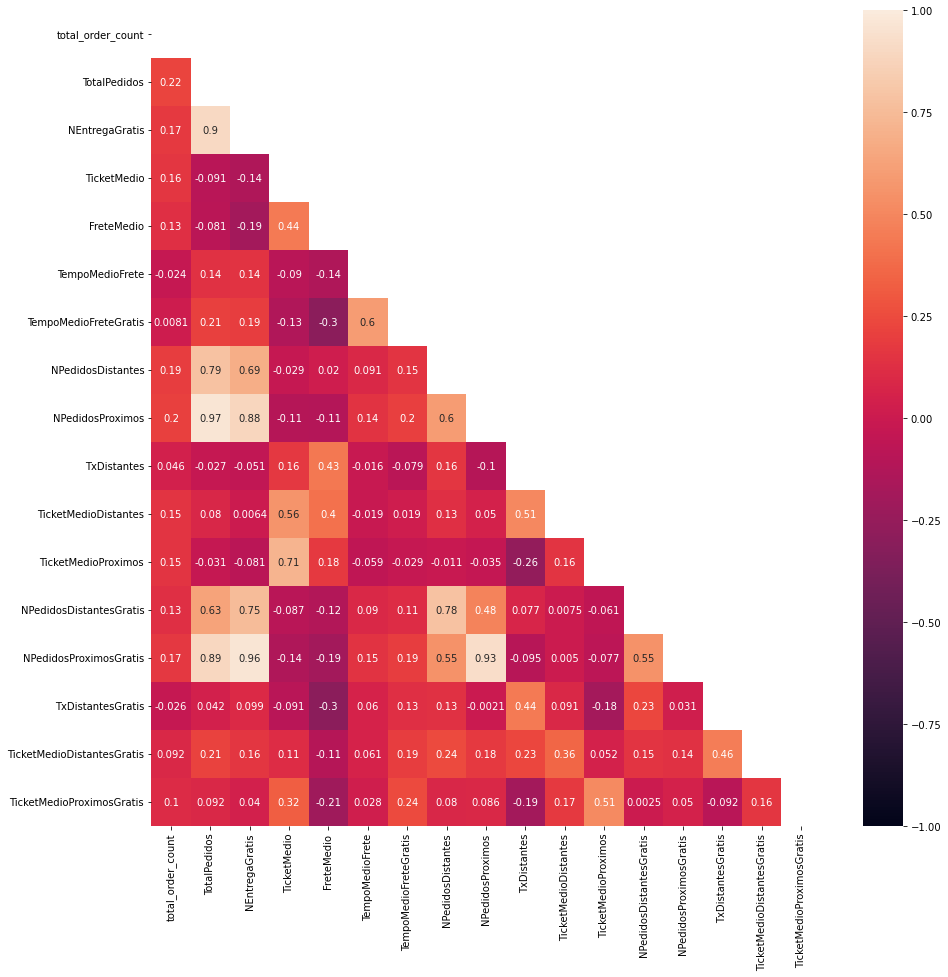

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

var_num = df_mkt_clean.select_dtypes(['int64', 'float64']).columns

plt.figure(figsize=(15,15))
sns.heatmap(df_mkt_clean[var_num].corr(), vmin=-1, vmax=+1, annot=True, 
            mask=np.triu(df_mkt_clean[var_num].corr()))

Variáveis que apresentaram uma forte correlação (>0.6):

- NEntregaGratis e TotalPedidos: 0.9
- NPedidosDistantes e TotalPedidos: 0.79
- NPedidosDistantes e NEntregaGratis: 0.69
- NPedidosProximos e TotalPedidos: 0.97
- NPedidosProximos e NEntregaGratis: 0.88
- TicketMedioProximos e TicketMedio: 0.71
- NPedidosDistantesGratis e TotalPedidos: 0.63
- NPedidosDistantesGratis e NEntregasGratis: 0.75
- NPedidosDistantesGratis e NPedidosDistantes: 0.78
- NPedidosProximosGratis e TotalPedidos: 0.89
- NPedidosProximosGratis e NEntregasGratis: 0.96
- NPedidosProximosGratis e NPedidosProximos: 0.93

Racionalizando sobre as hipóteses levantadas no início desse desafio:

- **Clientes com ticket médio menor costumam realizar pedidos com frete menor?**

Existe uma correlação moderada entre ticket médio e valor de frete médio (0.44). Sendo assim, é possível que exista uma relação de tal tipo.

- **Clientes com ticket médio maior priorizam uma entrega rápida**?

A correlação entre ticket médio e tempo médio de entrega é quase nula (-0.09), sendo bastante improvável uma relação desse tipo.

- **Os clientes realizam pedidos de restaurantes afastados (>3km) com menor frequência que em restaurantes próximos (<3km)**?

Sim, os pedidos em restaurantes afastados (>3km) correspondem a apenas 75% dos pedidos realizados.

- **Quando o cliente possui o benefício da entrega grátis, costuma pedir de restaurantes mais distantes que em pedidos convencionais**?

A correlação entre NPedidosDistantesGratis e NEntregaGratis é menor do que entre NPedidosProximosGratis e NEntregaGratis (0.75 versus 0.96). Não é possível, no entanto, determinar causalidade. É possível, e até bastante provável, que a disponibilidade de entregas grátis esteja associada aos estabelecimentos mais próximos.

- **Os clientes que compram com mais frequência tem um valor médio de frete menor que os demais?**

A correlação entre total de pedidos e frete médio é bastante fraca (-0.081), e portanto é improvável uma relação desse tipo.

- **Os clientes que compram com mais frequência tem um valor médio de tempo de entrega menor que os demais?**

Existe uma correlação fraca entre o número de pedidos e o tempo médio de frete (0.14), e embora não se possa descartar essa possibilidade, ela é pouco provável.

Vamos analisar o tipo de cozinha preferido em relação às demais variáveis numéricas, através de um boxplot:

In [65]:
df_mkt_clean['CozinhaMaisPedida'].value_counts()[0:5]

Lanches              3683
Comida Brasileira    3563
Comida Japonesa      1157
Pizza                1154
Doces & Bolos         630
Name: CozinhaMaisPedida, dtype: int64

In [66]:
df_mkt_clean['CozinhaMaisPedida'].value_counts()[0:5].sum()/df_mkt_clean['CozinhaMaisPedida'].value_counts().sum()

0.7295710090954666

Os cinco tipos de cozinha mais pedidos correspondem à preferência de mais de 70% dos clientes. Sendo assim, para facilitar o entendimento da análise, qualquer preferência que não esteja no top 5 será categorizada como "Outros".

In [67]:
cozinhas_top5 = df_mkt_clean['CozinhaMaisPedida'].value_counts()[0:5].index
cozinhas_top5

Index(['Lanches', 'Comida Brasileira', 'Comida Japonesa', 'Pizza',
       'Doces & Bolos'],
      dtype='object')

In [68]:
df_mkt_clean['CozinhaMaisPedida'] = df_mkt_clean['CozinhaMaisPedida'].apply(lambda x: x if x in cozinhas_top5 else 'Outros')

In [69]:
df_mkt_clean['CozinhaMaisPedida'].value_counts()

Outros               3776
Lanches              3683
Comida Brasileira    3563
Comida Japonesa      1157
Pizza                1154
Doces & Bolos         630
Name: CozinhaMaisPedida, dtype: int64

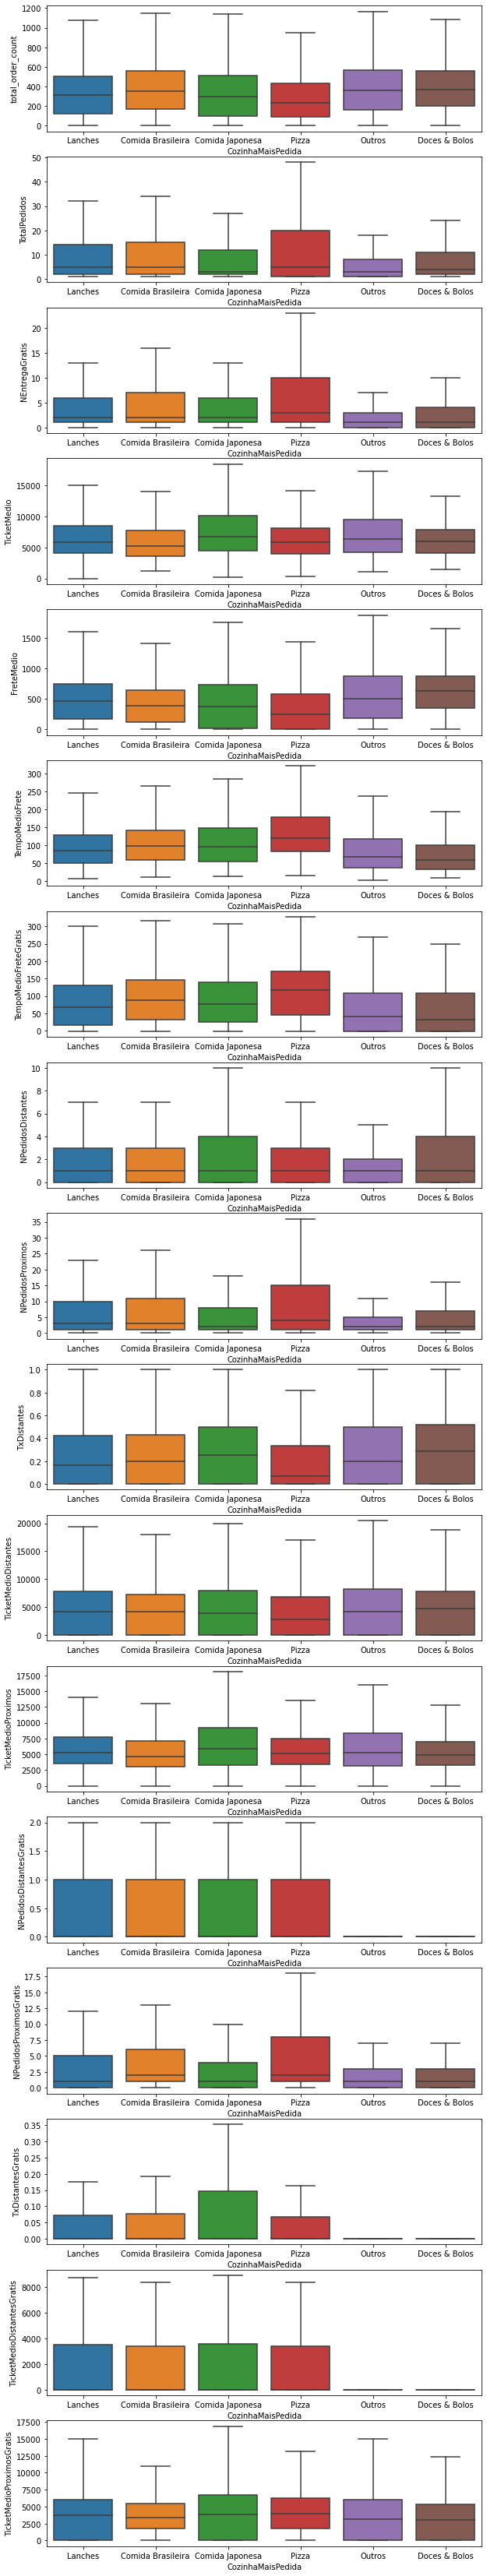

In [70]:
fig, axes = plt.subplots(len(var_num),1,figsize=(10,60))
i=0

for var in var_num:
    sns.boxplot(x=df_mkt_clean['CozinhaMaisPedida'], y=df_mkt_clean[var], ax=axes[i], showfliers=False)
    i=i+1

Algumas hipóteses que podem ser levantadas a partir dos gráficos acima, que respondem à hipótese inicial: **Existe uma relação entre o tipo de cozinha mais pedido e as preferências de entrega?**

- Clientes com preferência por pizza realizam mais pedidos;
- Clientes com preferência por pizza priorizam a entrega grátis;
- Clientes com preferência por comida japonesa possuem ticket médio maior;
- Clientes com preferência por pizza pagam menos em frete;
- Clientes com preferência por pizza esperam mais tempo pela entrega, em média;
- Clientes com preferência por comida japonesa tem maior tendência a pedir em restaurantes distantes;
- Clientes com preferência por pizza tem maior tendência a pedir em restaurantes próximos.

Para definir o teste estatístico adequado, devemos verificar a distribuição das variáveis numéricas:

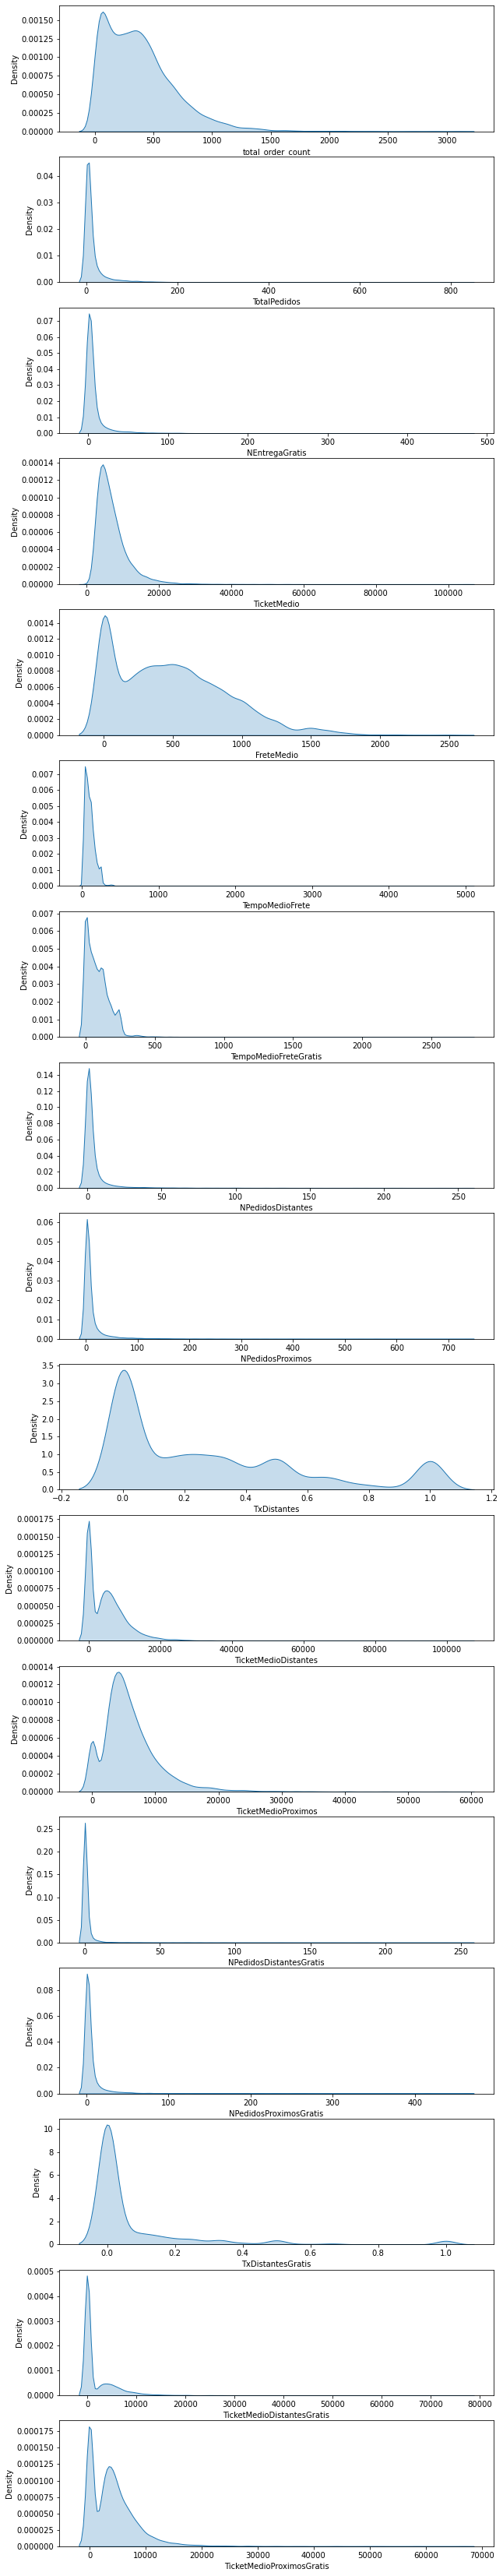

In [71]:
fig, axes = plt.subplots(len(var_num),1,figsize=(10,60))
i=0

for var in var_num:
    sns.kdeplot(df_mkt_clean[var], shade=True, ax=axes[i])
    i=i+1

As distribuições são, de modo geral, do tipo cauda longa com assimetria positiva (para a direita). O teste adequado, dada a distribuição dos dados, seria o teste não-paramétrico de Kruskal-Wallis.

In [88]:
grp1 = df_mkt_clean.loc[df_mkt_clean['CozinhaMaisPedida']=='Lanches']
grp2 = df_mkt_clean.loc[df_mkt_clean['CozinhaMaisPedida']=='Comida Brasileira']
grp3 = df_mkt_clean.loc[df_mkt_clean['CozinhaMaisPedida']=='Comida Japonesa']
grp4 = df_mkt_clean.loc[df_mkt_clean['CozinhaMaisPedida']=='Pizza']
grp5 = df_mkt_clean.loc[df_mkt_clean['CozinhaMaisPedida']=='Outros']
grp6 = df_mkt_clean.loc[df_mkt_clean['CozinhaMaisPedida']=='Doces & Bolos']

In [104]:
from scipy.stats import kruskal

var_kruskal = ['TotalPedidos', 'NEntregaGratis', 'TicketMedio', 'FreteMedio', 'TempoMedioFrete', 'TxDistantes']

for var in var_kruskal:
    stat, p = kruskal(grp1[var], grp2[var], grp3[var], grp4[var], grp5[var], grp6[var])
    print(var)
    print('Estatística = %.3f, p-valor = %.3f' % (stat, p))
    alpha = 0.05
    if p > alpha:
        print('Mesmas distribuições (falha em rejeitar H0)\n')
    else:
        print('Distribuições diferentes (rejeita H0)\n')

TotalPedidos
Estatística = 272.497, p-valor = 0.000
Distribuições diferentes (rejeita H0)

NEntregaGratis
Estatística = 451.730, p-valor = 0.000
Distribuições diferentes (rejeita H0)

TicketMedio
Estatística = 244.301, p-valor = 0.000
Distribuições diferentes (rejeita H0)

FreteMedio
Estatística = 404.369, p-valor = 0.000
Distribuições diferentes (rejeita H0)

TempoMedioFrete
Estatística = 826.632, p-valor = 0.000
Distribuições diferentes (rejeita H0)

TxDistantes
Estatística = 98.699, p-valor = 0.000
Distribuições diferentes (rejeita H0)



A hipótese nula do teste de Kruskal-Wallis é de que não existe diferença de valores da variável numérica dentro dos grupos da variável categórica avaliada (CozinhaMaisPedida). Como o p-valor foi menor que o nível de significância escolhido, de 0.05, podemos rejeitar a hipótese nula.

O teste poc-hoc de comparação múltipla de Nemenyi será utilizado para investigar quais dos grupos se diferenciam entre si. 

In [111]:
import scikit_posthocs as sp

for var in var_kruskal:
    print(var)
    print(sp.posthoc_nemenyi(df_mkt_clean, val_col=var, group_col='CozinhaMaisPedida'))
    print('\n')

TotalPedidos
                   Comida Brasileira  Comida Japonesa  Doces & Bolos  \
Comida Brasileira       1.000000e+00         0.000370       0.000354   
Comida Japonesa         3.703045e-04         1.000000       0.974714   
Doces & Bolos           3.538542e-04         0.974714       1.000000   
Lanches                 3.599503e-02         0.337028       0.130825   
Outros                  2.502976e-48         0.000003       0.033503   
Pizza                   8.540726e-01         0.184946       0.066044   

                        Lanches        Outros         Pizza  
Comida Brasileira  3.599503e-02  2.502976e-48  8.540726e-01  
Comida Japonesa    3.370285e-01  2.791494e-06  1.849460e-01  
Doces & Bolos      1.308248e-01  3.350323e-02  6.604388e-02  
Lanches            1.000000e+00  9.154139e-29  9.630344e-01  
Outros             9.154139e-29  1.000000e+00  1.009781e-16  
Pizza              9.630344e-01  1.009781e-16  1.000000e+00  


NEntregaGratis
                   Comida Brasi

## Produtização

Para gerar os clusters de clientes, será utilizado o modelo K-Prototype. Esse é uma derivação do clássico algoritmo K-Means, adaptado para trabalhar com variáveis categóricas, como "CozinhaMaisPedida". O primeiro passo é selecionar as variáveis que serão utilizadas para a produção do modelo e padronizar as variáveis numéricas. 

In [72]:
df_mkt_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 13963 entries, 0 to 20246
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   account_id                  13963 non-null  object 
 1   registration_date           13963 non-null  object 
 2   ifood_status                13963 non-null  object 
 3   ifood_status_last_month     13963 non-null  object 
 4   total_order_count           13963 non-null  int64  
 5   first_order_date            13963 non-null  object 
 6   TotalPedidos                13963 non-null  float64
 7   NEntregaGratis              13963 non-null  int64  
 8   TicketMedio                 13963 non-null  float64
 9   FreteMedio                  13963 non-null  float64
 10  TempoMedioFrete             13963 non-null  float64
 11  TempoMedioFreteGratis       13963 non-null  float64
 12  CozinhaMaisPedida           13963 non-null  object 
 13  NPedidosDistantes           139

Dado o objetivo da análise, as variáveis "account_id", "registration_date", "ifood_status", "ifood_status_last_month", "total_order_count" e "first_order_date" podem ser negligenciadas, em um primeiro momento. Todas as outras variáveis serão utilizadas.

In [73]:
X = df_mkt_clean.iloc[:,6:]

X.head()

,TotalPedidos,NEntregaGratis,TicketMedio,FreteMedio,TempoMedioFrete,TempoMedioFreteGratis,CozinhaMaisPedida,NPedidosDistantes,NPedidosProximos,TxDistantes,TicketMedioDistantes,TicketMedioProximos,NPedidosDistantesGratis,NPedidosProximosGratis,TxDistantesGratis,TicketMedioDistantesGratis,TicketMedioProximosGratis
0,2.0,2,5619.375,0.0000,127.500000,127.50,Lanches,0.0,2.0,0.00,-1.0,5619.375,0.0,2.0,0.00,-1.0,5619.375
2,5.0,4,2424.000,175.0000,109.600000,77.00,Comida Brasileira,0.0,5.0,0.00,-1.0,2424.000,0.0,4.0,0.00,-1.0,1873.750
3,4.0,2,9235.625,434.0625,189.000000,240.00,Lanches,1.0,3.0,0.25,2112.5,11610.000,1.0,1.0,0.25,2112.5,20162.500
5,2.0,1,29798.750,806.2500,62.000000,44.00,Comida Japonesa,1.0,1.0,0.50,54112.5,5485.000,0.0,1.0,0.00,-1.0,5485.000
6,6.0,4,4238.750,125.0000,61.666667,61.25,Pizza,0.0,6.0,0.00,-1.0,4238.750,0.0,4.0,0.00,-1.0,4530.000


In [74]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 13963 entries, 0 to 20246
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   TotalPedidos                13963 non-null  float64
 1   NEntregaGratis              13963 non-null  int64  
 2   TicketMedio                 13963 non-null  float64
 3   FreteMedio                  13963 non-null  float64
 4   TempoMedioFrete             13963 non-null  float64
 5   TempoMedioFreteGratis       13963 non-null  float64
 6   CozinhaMaisPedida           13963 non-null  object 
 7   NPedidosDistantes           13963 non-null  float64
 8   NPedidosProximos            13963 non-null  float64
 9   TxDistantes                 13963 non-null  float64
 10  TicketMedioDistantes        13963 non-null  float64
 11  TicketMedioProximos         13963 non-null  float64
 12  NPedidosDistantesGratis     13963 non-null  float64
 13  NPedidosProximosGratis      139

In [75]:
var_num = X.select_dtypes(['int64', 'float64'])
for var in var_num:
    X[var] = (X[var]-X[var].mean())/X[var].std()

X.head()

,TotalPedidos,NEntregaGratis,TicketMedio,FreteMedio,TempoMedioFrete,TempoMedioFreteGratis,CozinhaMaisPedida,NPedidosDistantes,NPedidosProximos,TxDistantes,TicketMedioDistantes,TicketMedioProximos,NPedidosDistantesGratis,NPedidosProximosGratis,TxDistantesGratis,TicketMedioDistantesGratis,TicketMedioProximosGratis
0,-0.364307,-0.251557,-0.302394,-1.196954,0.282750,0.371413,Lanches,-0.330306,-0.333541,-0.873232,-0.842068,-0.083763,-0.189933,-0.242010,-0.425890,-0.498982,0.357147
2,-0.287367,-0.175080,-0.969249,-0.764907,0.087408,-0.108049,Comida Brasileira,-0.330306,-0.233568,-0.873232,-0.842068,-0.766344,-0.189933,-0.144881,-0.425890,-0.498982,-0.515994
3,-0.313013,-0.251557,0.452296,-0.125323,0.953898,1.439521,Lanches,-0.251585,-0.300217,-0.092290,-0.484462,1.195926,-0.070885,-0.290575,0.912853,0.053604,3.747286
5,-0.364307,-0.289795,4.743696,0.793549,-0.432050,-0.421361,Comida Japonesa,-0.251585,-0.366866,0.688651,8.313984,-0.112468,-0.189933,-0.290575,-0.425890,-0.498982,0.325823
6,-0.261720,-0.175080,-0.590522,-0.888349,-0.435688,-0.257584,Pizza,-0.330306,-0.200243,-0.873232,-0.842068,-0.378686,-0.189933,-0.144881,-0.425890,-0.498982,0.103203


In [76]:
# from kmodes.kprototypes import KPrototypes

# XMatrix = X.to_numpy()

# K = range(1,10)

# cost = []

# for num_clusters in K:
#     kprototype = KPrototypes(n_jobs = -1, n_clusters = num_clusters, init = 'Huang', random_state = 42)
#     kprototype.fit_predict(XMatrix, categorical = [6])
#     cost.append(kprototype.cost_)

# plt.plot(cost)

De acordo com o gráfico, será escolhido um número de clusters igual a 6 (equivalente ao número 5 no gráfico). Um ponto sensível dessa escolha é o tradeoff entre obter clusters mais distintos e possuir um número adequado para tratativas diferenciadas de negócio. A princípio, será considerado que é possível realizar até 6 diferentes tratativas, de acordo com os clusters gerados.

In [77]:
from kmodes.kprototypes import KPrototypes

XMatrix = X.to_numpy()

kprototype = KPrototypes(n_jobs = -1, n_clusters = 6, init = 'Huang', random_state = 42)
kprototype.fit_predict(XMatrix, categorical = [6])

array([2, 2, 3, ..., 1, 2, 2], dtype=uint16)

In [78]:
df_mkt_clean['cluster'] = kprototype.labels_

df_mkt_clean.head()

,account_id,registration_date,ifood_status,ifood_status_last_month,total_order_count,first_order_date,TotalPedidos,NEntregaGratis,TicketMedio,FreteMedio,...,NPedidosProximos,TxDistantes,TicketMedioDistantes,TicketMedioProximos,NPedidosDistantesGratis,NPedidosProximosGratis,TxDistantesGratis,TicketMedioDistantesGratis,TicketMedioProximosGratis,cluster
0,7c0450e7-a806-4208-8449-e4269a27e6b5,2020-02-02,Inactive,Inactive,8,2020-02-28,2.0,2,5619.375,0.0000,...,2.0,0.00,-1.0,5619.375,0.0,2.0,0.00,-1.0,5619.375,2
2,61c051ee-d37c-45c6-8c22-c236db3b62b7,2018-09-02,Active,Active,206,2018-09-02,5.0,4,2424.000,175.0000,...,5.0,0.00,-1.0,2424.000,0.0,4.0,0.00,-1.0,1873.750,2
3,82e48692-e4fa-494e-b03e-6815a819b7b1,2017-11-10,Reactivated,Churn,47,2018-05-01,4.0,2,9235.625,434.0625,...,3.0,0.25,2112.5,11610.000,1.0,1.0,0.25,2112.5,20162.500,3
5,3e9190e8-528d-458a-b8a5-4cdb6e1ebddc,2013-10-27,Inactive,Inactive,533,2013-10-26,2.0,1,29798.750,806.2500,...,1.0,0.50,54112.5,5485.000,0.0,1.0,0.00,-1.0,5485.000,3
6,4de372d2-75f9-4a3a-ac08-59d1c974e433,2019-05-04,Active,Active,69,2019-12-20,6.0,4,4238.750,125.0000,...,6.0,0.00,-1.0,4238.750,0.0,4.0,0.00,-1.0,4530.000,2


In [79]:
df_mkt_clean['cluster'].value_counts()

2    6910
1    2487
5    1976
3    1708
4     802
0      80
Name: cluster, dtype: int64

In [80]:
df_mkt_clean.groupby('cluster').agg(['mean'])

,total_order_count,TotalPedidos,NEntregaGratis,TicketMedio,FreteMedio,TempoMedioFrete,TempoMedioFreteGratis,NPedidosDistantes,NPedidosProximos,TxDistantes,TicketMedioDistantes,TicketMedioProximos,NPedidosDistantesGratis,NPedidosProximosGratis,TxDistantesGratis,TicketMedioDistantesGratis,TicketMedioProximosGratis
,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean
cluster,,,,,,,,,,,,,,,,,
0,895.550000,332.012500,252.512500,3110.986324,156.126895,186.884351,187.045636,101.087500,230.925000,0.332455,3209.466731,3013.794592,81.375000,171.137500,0.282160,2977.046723,2936.759647
1,375.716928,13.022517,7.082429,6353.730026,310.085044,127.371363,141.081791,5.171693,7.850824,0.514275,6986.153872,4958.823979,2.616807,4.465621,0.360190,6852.445027,3872.648713
2,332.365123,7.363242,3.797395,5220.277056,348.971023,97.482299,84.299497,0.886831,6.476411,0.074377,1794.040819,5166.455791,0.170478,3.626918,0.011721,383.637315,3582.273687
3,471.663934,10.703162,2.962529,14433.396870,694.254276,86.682738,81.706778,3.070843,7.632319,0.236127,9249.838001,14250.241333,0.252342,2.710187,0.017437,1474.751878,9841.636687
4,519.514963,112.689526,62.345387,5620.627925,345.507262,138.080795,152.139365,26.326683,86.362843,0.228216,6207.074168,5379.205648,9.441397,52.903990,0.091052,4760.647914,5083.586288
5,404.560729,3.938259,0.338057,8812.125819,1068.652205,78.130982,12.217329,2.607287,1.330972,0.757795,9449.024814,3548.127088,0.039474,0.298583,0.004218,185.257064,791.679243


### Total de pedidos e Número de entregas grátis

- O cluster 0 é o que realiza mais pedidos, seguido pelo cluster 4. Não parece haver diferença significativa entre os demais clusters;

- O comportamento em relação ao número de pedidos não parece mudar quando o frete é grátis.

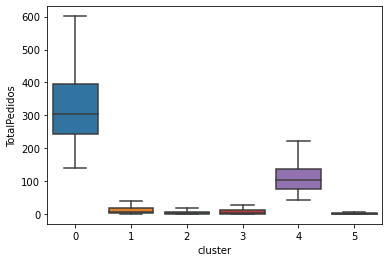

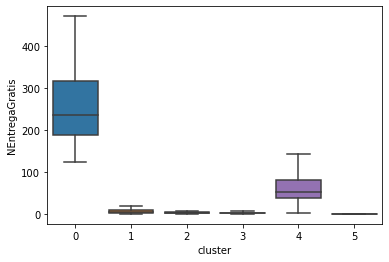

In [81]:
sns.boxplot(x=df_mkt_clean['cluster'], y=df_mkt_clean['TotalPedidos'], showfliers=False)
plt.figure()
sns.boxplot(x=df_mkt_clean['cluster'], y=df_mkt_clean['NEntregaGratis'], showfliers=False);

### Ticket Médio e Frete Médio

- O cluster 3 possui o maior ticket médio, seguido pelo cluster 5. Na outra ponta, o cluster 0 agrega os clientes com menor ticket médio;

- O cluster 5 possui o maior valor médio em frente, seguido pelo cluster 3. Por outro lado, o cluster 0 apresenta o menor valor médio de frete.

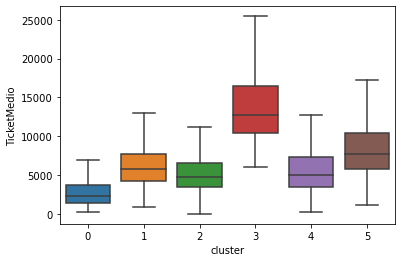

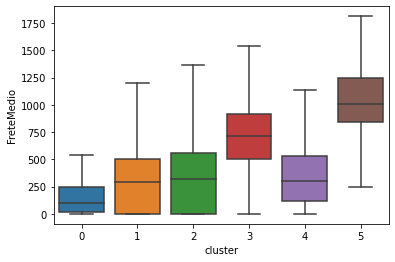

In [82]:
sns.boxplot(x=df_mkt_clean['cluster'], y=df_mkt_clean['TicketMedio'], showfliers=False);
plt.figure()
sns.boxplot(x=df_mkt_clean['cluster'], y=df_mkt_clean['FreteMedio'], showfliers=False);

### Tempo Médio Frete e Tempo Médio Frete Grátis

- O cluster 0 possui o maior tempo médio de frete, seguido pelo cluster 4. O cluster 5 possui um tempo de frete ligeiramente menor;
- O cluster 5 raramente realiza pedidos com frete grátis (são outliers).

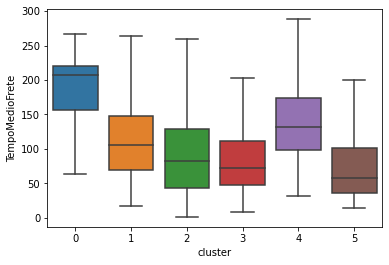

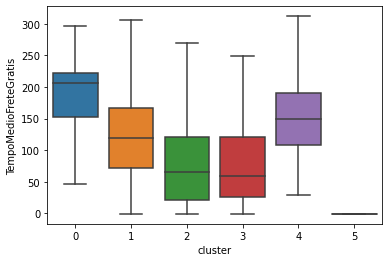

In [83]:
sns.boxplot(x=df_mkt_clean['cluster'], y=df_mkt_clean['TempoMedioFrete'], showfliers=False);
plt.figure()
sns.boxplot(x=df_mkt_clean['cluster'], y=df_mkt_clean['TempoMedioFreteGratis'], showfliers=False);

### Taxa de Pedidos Distantes e Taxa de Pedidos Distantes Grátis

- O cluster 5 realiza pedidos em restaurantes mais distantes, seguido pelo cluster 1. Por outro lado, os clientes do cluster 2 raramente realizam pedidos em restaurantes distantes (para mais de 75%, menos de 20% das vezes);
- Os clusters 2, 3 e 5 não realizam pedidos em restaurantes distantes com frete grátis. Os clusters 0 e 1 realizam a mesma proporção de pedidos em restaurantes distantes quando o frete é grátis (em relação a quando não é).

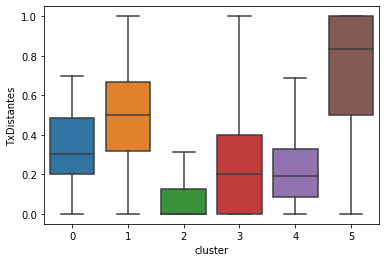

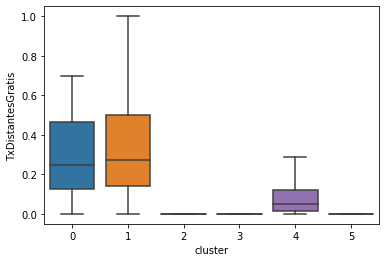

In [84]:
sns.boxplot(x=df_mkt_clean['cluster'], y=df_mkt_clean['TxDistantes'], showfliers=False);
plt.figure()
sns.boxplot(x=df_mkt_clean['cluster'], y=df_mkt_clean['TxDistantesGratis'], showfliers=False);

### Ticket Médio em Restaurantes Distantes/Próximos

- O cluster 5 gasta mais em restaurantes distantes, ao contrário dos clusters 2 e 3. O cluster 3 gasta consideravelmente menos em restaurantes distantes, ao passo em que os gastos do cluster 2 em restaurantes distantes são muitos menores.

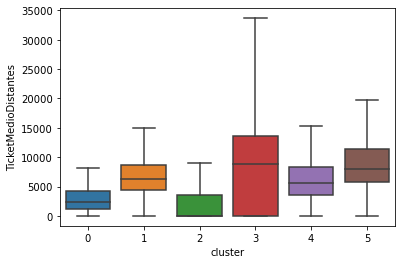

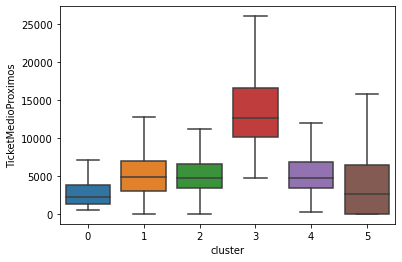

In [85]:
sns.boxplot(x=df_mkt_clean['cluster'], y=df_mkt_clean['TicketMedioDistantes'], showfliers=False);
plt.figure()
sns.boxplot(x=df_mkt_clean['cluster'], y=df_mkt_clean['TicketMedioProximos'], showfliers=False);

### Ticket Médio em Restaurantes Distantes/Próximos Grátis

- Os clusters 0, 1 e 4 tem um ticket médio em restaurantes distantes parecido quando o frete é grátis;
- O cluster 1 tem mais clientes com ticket médio baixo em restaurantes próximos quando o frete é grátis (primeiro quartil menor).

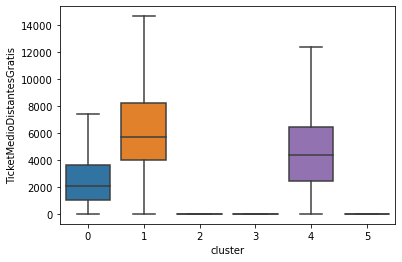

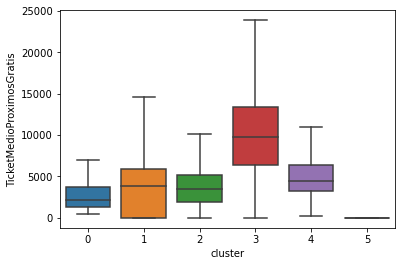

In [86]:
sns.boxplot(x=df_mkt_clean['cluster'], y=df_mkt_clean['TicketMedioDistantesGratis'], showfliers=False);
plt.figure()
sns.boxplot(x=df_mkt_clean['cluster'], y=df_mkt_clean['TicketMedioProximosGratis'], showfliers=False);

### Cozinha Mais Pedida

- O cluster 0 tem a maior proporção (em relação ao total) de clientes cuja cozinha mais pedida é japonesa;
- O cluster 5 tem a maior proporção de clientes cuja cozinha mais pedida se encaixa em "outros", seguido pelo cluster 3;
- O cluster 4 tem a maior proporção de clientes cuja cozinha mais pedida é pizza;
- Em geral, os clusters estão bem divididos em relação às preferências culinárias.

<AxesSubplot:xlabel='cluster', ylabel='count'>

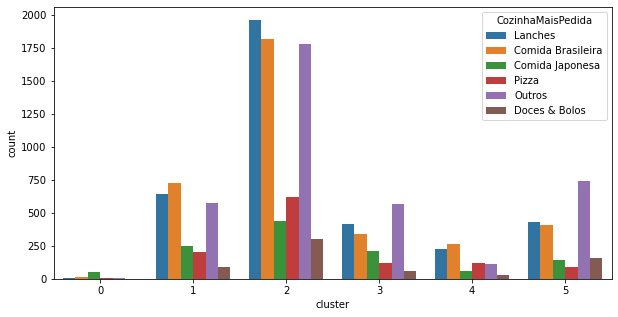

In [87]:
cluster = df_mkt_clean['cluster'].astype('object')
plt.figure(figsize=(10,5))
sns.countplot(x=cluster, hue=df_mkt_clean['CozinhaMaisPedida'])

### Descrição dos clusters

- **Cluster 0**: clientes que realizam mais pedidos, com ou sem frete grátis, com menor ticket médio, menor valor de frete e maior tempo médio de frete.

*Análise*: São clientes que pedem muito e gastam pouco, não se importam de esperar bastante pelo pedido desde que o frete seja barato. Possíveis tratamentos aplicáveis à esse cluster: promoções que incentivem o consumo, visando aumentar o ticket médio, como vendas casadas (combos, compre dois leve três, desconto a partir de determinado valor gasto) e mais cupons de frete grátis ou desconto em frete. Para baratear o custo operacional do frete, é possível direcionar esses clientes a entregadores por bicleta ou outras opções em conta, mesmo que o tempo de entrega aumente.

- **Cluster 1**: clientes que pedem pouco, porém bastante em restaurantes distantes.

*Análise*: Esses clientes pedem pouco, sendo necessárias ações de retenção. Como esses clientes pedem bastante em restaurantes distantes, tem um tempo médio de frete acima da média e um custo médio de frete abaixo da média, é possível que o valor de frete seja um empecilho, ou sua relação com o tempo de entrega. Oferecer serviço de cashback pode ser uma opção viável. 

- **Cluster 2**: clientes que pedem pouco, raramente podem em restaurantes distantes.

*Análise*: É preciso fidelizar essa parte dos clientes, antes de atender qualquer necessidade específica de entrega (que aparentemente não possuem). Realizam tão poucos pedidos que por vezes ainda não é possível compreender o verdadeiro perfil de consumo desses. Possíveis tratativas: oferecer serviços de cashback, envio de cupons com promoções em restaurantes próximos, envio de email com destaques do cardápio em restaurantes próximos.

- **Cluster 3**: clientes que possuem o maior ticket médio, gastam bastante com frete, mas gastam mais nos restaurantes mais próximos.

*Análise*: Esse grupo de clientes pede mais em restaurantes mais próximos e ainda assim não tem problema em gastar bastante com frete, desde que seja suficientemente rápido. Talvez fosse efetivo fomentar o consumo desses em restaurantes mais distantes, dado que podem pagar um pouco a mais. Para isso, estudar opções de frete expresso, mesmo que custe um pouco a mais, pode ser interessante. 

- **Cluster 4**: clientes que realizam muitos pedidos, com ou sem entrega grátis, com alto tempo médio de frete.

*Análise*: Os clientes desse cluster realizam muitos pedidos, não tem um ticket médio destacável, e possuem um alto tempo médio de frete. Não parecem ter um comportamento específico em relação à entrega grátis e distância do restaurante. Uma linha interessante seriam formas de aumentar o ticket médio, com vendas casadas e descontos a partir de determinado valor gasto, por exemplo.

- **Cluster 5**: clientes com alto ticket médio, o maior valor gasto em frete, o menor tempo médio de frete, não utilizam frete grátis, pedem em restaurantes distantes, gastam mais nos restaurantes distantes.

*Análise*: Esses clientes não tem problemas em gastar mais e pedir em restaurantes distantes, desde que o frete seja rápido. Uma ação efetiva seria, assim como para o cluster 3, estudar formas de entrega mais rápidas, ainda que mais caras.